In [114]:
import pickle

pkl_path = "E:/Experiment/data/ti_500K_pseudo_labeled.pickle"

with open(pkl_path, "rb") as f:
    data = pickle.load(f)


In [115]:
type(data)


dict

In [116]:
if isinstance(data, dict):
    print(data.keys())


dict_keys(['data', 'extrapolated_targets', 'ti_index', 'prediction_model', 'prediction_model_epoch'])


In [159]:
import numpy as np
import torch

X = data["data"]
Y = data["extrapolated_targets"]

print(type(X), type(Y))

if isinstance(X, np.ndarray):
    print("X shape:", X.shape, "dtype:", X.dtype)

if isinstance(Y, np.ndarray):
    print("Y shape:", Y.shape, "dtype:", Y.dtype)

# Check label range
print("Label min:", Y.min())
print("Label max:", Y.max())


<class 'numpy.ndarray'> <class 'numpy.ndarray'>
X shape: (500000, 32, 32, 3) dtype: uint8
Y shape: (500000,) dtype: int64
Label min: 0
Label max: 9


In [118]:
import numpy as np

def extract_balanced_subset(X, Y, total_size, seed=42):
    """
    Extract a class-balanced subset of (X, Y) with a given total size.

    Args:
        X (np.ndarray): shape (N, H, W, C)
        Y (np.ndarray): shape (N,)
        total_size (int): total number of samples to extract
        seed (int): random seed

    Returns:
        X_sub, Y_sub (np.ndarray, np.ndarray)
    """
    np.random.seed(seed)

    classes = np.unique(Y)
    num_classes = len(classes)

    if total_size % num_classes != 0:
        raise ValueError(
            f"total_size={total_size} not divisible by num_classes={num_classes}"
        )

    samples_per_class = total_size // num_classes
    selected_indices = []

    for c in classes:
        class_indices = np.where(Y == c)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Class {c} has only {len(class_indices)} samples, "
                f"need {samples_per_class}"
            )

        chosen = np.random.choice(
            class_indices, samples_per_class, replace=False
        )
        selected_indices.append(chosen)

    selected_indices = np.concatenate(selected_indices)
    np.random.shuffle(selected_indices)

    return X[selected_indices], Y[selected_indices]

X_ft, Y_ft = extract_balanced_subset(
    X, Y,
    total_size=10_000,
    seed=0
)

print(X_ft.shape, Y_ft.shape)

(10000, 32, 32, 3) (10000,)


In [5]:
print(X[0].shape)

(32, 32, 3)


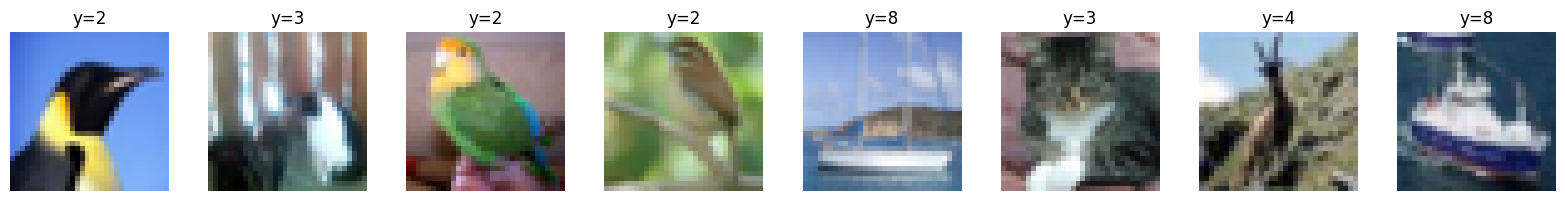

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_random_samples(X, Y, num_samples=8, seed=42):
    np.random.seed(seed)
    idxs = np.random.choice(len(X), num_samples, replace=False)

    fig, axes = plt.subplots(1, num_samples, figsize=(2*num_samples, 2))
    for ax, idx in zip(axes, idxs):
        ax.imshow(X[idx])
        ax.set_title(f"y={Y[idx]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_random_samples(X, Y, num_samples=8)


In [ ]:
def visualize_per_class(X, Y, num_per_class=3, seed=42):
    np.random.seed(seed)
    classes = np.unique(Y)

    fig, axes = plt.subplots(len(classes), num_per_class,
                             figsize=(num_per_class*2, len(classes)*2))

    for i, c in enumerate(classes):
        idxs = np.where(Y == c)[0]
        chosen = np.random.choice(idxs, num_per_class, replace=False)

        for j, idx in enumerate(chosen):
            axes[i, j].imshow(X[idx])
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_ylabel(f"class {c}")

    plt.tight_layout()
    plt.show()
    
visualize_per_class(X, Y)

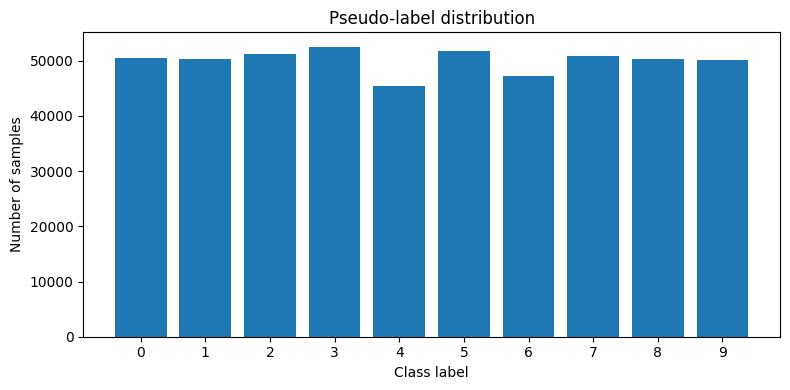

Counter({np.int64(3): 52509, np.int64(5): 51743, np.int64(2): 51226, np.int64(7): 50811, np.int64(0): 50443, np.int64(8): 50344, np.int64(1): 50246, np.int64(9): 50142, np.int64(6): 47156, np.int64(4): 45380})


In [8]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_label_distribution(Y):
    counter = Counter(Y)
    labels = sorted(counter.keys())
    counts = [counter[l] for l in labels]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, counts)
    plt.xlabel("Class label")
    plt.ylabel("Number of samples")
    plt.title("Pseudo-label distribution")
    plt.xticks(labels)
    plt.tight_layout()
    plt.show()

    return counter
    
label_stats = plot_label_distribution(Y)
print(label_stats)

In [18]:
import numpy as np
from torch.utils.data import Subset

def create_overlapping_groups(
    dataset,
    group_size=25_000,
    overlap_rate=0.0,
    seed=42
):
    """
    Create two fixed-size training groups with a controllable overlap.

    Args:
        dataset: PyTorch dataset (CIFAR-10 or CIFAR-100 train set)
        group_size: number of samples per group (default 25k)
        overlap_rate: fraction of overlap in [0, 1]
        seed: random seed for reproducibility

    Returns:
        subset_A, subset_B, stats_dict
    """
    assert 0.0 <= overlap_rate <= 1.0

    N = len(dataset)
    assert N >= 2 * group_size * (1 - overlap_rate), \
        "Dataset too small for requested overlap and group size"

    rng = np.random.default_rng(seed)
    all_indices = np.arange(N)
    rng.shuffle(all_indices)

    K = int(group_size * overlap_rate)     # overlap
    U = group_size - K                     # unique per group

    overlap_idx = all_indices[:K]
    unique_A_idx = all_indices[K:K + U]
    unique_B_idx = all_indices[K + U:K + 2 * U]

    group_A_idx = np.concatenate([overlap_idx, unique_A_idx])
    group_B_idx = np.concatenate([overlap_idx, unique_B_idx])

    # Shuffle within groups (important)
    rng.shuffle(group_A_idx)
    rng.shuffle(group_B_idx)

    subset_A = Subset(dataset, group_A_idx.tolist())
    subset_B = Subset(dataset, group_B_idx.tolist())

    stats = {
        "total_samples": N,
        "group_size": group_size,
        "overlap_rate": overlap_rate,
        "overlap_count": K,
        "unique_per_group": U,
        "distinct_used": 2 * group_size - K
    }

    return subset_A, subset_B, stats


In [19]:
from Dataset.CIFAR_10 import CIFAR10Dataset

train_set = CIFAR10Dataset().train_set

group_A, group_B, stats = create_overlapping_groups(
    dataset=train_set,
    group_size=25000,
    overlap_rate=0.3,   # 30% overlap
    seed=42
)


In [22]:
group_A[0]

(tensor([[[-1.7665, -1.7665, -1.8141,  ...,  1.0426,  1.0108,  0.9474],
          [-1.6078, -1.5919, -1.6554,  ...,  1.0743,  1.0267,  0.9632],
          [-1.5284, -1.4808, -1.6237,  ...,  1.1378,  1.0584,  0.9950],
          ...,
          [ 0.4712,  0.5823,  0.3443,  ...,  0.1062,  0.0110, -0.0366],
          [-1.9887, -1.9887, -1.9887,  ..., -1.9887, -1.9887, -1.9887],
          [-1.9887, -1.9887, -1.9887,  ..., -1.9887, -1.9887, -1.9887]],
 
         [[-1.7548, -1.7226, -1.7709,  ...,  1.0152,  0.9830,  0.9025],
          [-1.6260, -1.6260, -1.6582,  ...,  1.0475,  0.9991,  0.9347],
          [-1.5616, -1.5293, -1.6260,  ...,  1.1119,  1.0152,  0.9669],
          ...,
          [ 0.5643,  0.6126,  0.3710,  ...,  0.1617,  0.0650,  0.0167],
          [-1.9803, -1.9803, -1.9803,  ..., -1.9803, -1.9803, -1.9803],
          [-1.9803, -1.9803, -1.9803,  ..., -1.9803, -1.9803, -1.9803]],
 
         [[-1.5419, -1.5269, -1.6019,  ...,  0.7966,  0.7667,  0.7067],
          [-1.5119, -1.4819,

In [16]:
overlap_idx

array([  712, 24774, 45142, ...,  2076, 23205, 38780], shape=(12500,))

In [17]:
unique_A_idx 

array([26510, 11445, 39431, ..., 36198, 49885,  7560], shape=(12500,))

In [38]:
from collections import Counter

def get_class_distribution(dataset, num_classes=None):
    """
    Compute class distribution for a Dataset or Subset.

    Returns:
        dict {class_id: count}
    """
    labels = []

    if hasattr(dataset, "indices"):  # Subset
        for idx in dataset.indices:
            _, y = dataset.dataset[idx]
            labels.append(y)
    else:  # full dataset
        for _, y in dataset:
            labels.append(y)

    counter = Counter(labels)

    if num_classes is not None:
        return {c: counter.get(c, 0) for c in range(num_classes)}

    return dict(counter)

from collections import Counter
import numpy as np
from torch.utils.data import Subset

def get_class_distribution1(obj, dataset=None, num_classes=None):
    """
    Get class distribution from:
      - full Dataset
      - Subset
      - index list / numpy array (requires original dataset)

    Args:
        obj: Dataset | Subset | list[int] | np.ndarray
        dataset: original dataset (required if obj is indices)
        num_classes: optional, force full class keys

    Returns:
        dict {class_id: count}
    """
    labels = []

    # Case 1: Subset
    if isinstance(obj, Subset):
        for idx in obj.indices:
            _, y = obj.dataset[idx]
            labels.append(y)

    # Case 2: raw indices (list or ndarray)
    elif isinstance(obj, (list, np.ndarray)):
        assert dataset is not None, \
            "Original dataset must be provided when using index lists"
        for idx in obj:
            _, y = dataset[int(idx)]
            labels.append(y)

    # Case 3: full dataset
    else:
        for item in obj:
            # item can be (x, y) or (x, y, ...)
            y = item[1]
            labels.append(y)

    counter = Counter(labels)

    if num_classes is not None:
        return {c: counter.get(c, 0) for c in range(num_classes)}

    return dict(counter)



In [24]:
dist_A = get_class_distribution(group_A, num_classes=10)
dist_B = get_class_distribution(group_B, num_classes=10)

print("Group A:", dist_A)
print("Group B:", dist_B)


Group A: {0: 2504, 1: 2537, 2: 2518, 3: 2470, 4: 2536, 5: 2488, 6: 2418, 7: 2484, 8: 2540, 9: 2505}
Group B: {0: 2516, 1: 2492, 2: 2512, 3: 2461, 4: 2489, 5: 2490, 6: 2508, 7: 2562, 8: 2503, 9: 2467}


In [25]:
import numpy as np
from collections import defaultdict
from torch.utils.data import Subset

def create_class_balanced_overlapping_groups(
    dataset,
    group_size=25_000,
    overlap_rate=0.0,
    num_classes=10,
    seed=42
):
    """
    Create two class-balanced training subsets with a controllable overlap.

    Args:
        dataset: CIFAR-10 or CIFAR-100 training dataset
        group_size: total samples per group (default 25k)
        overlap_rate: fraction of overlap per class [0,1]
        num_classes: 10 (CIFAR-10) or 100 (CIFAR-100)
        seed: reproducibility seed

    Returns:
        subset_A, subset_B, stats
    """
    rng = np.random.default_rng(seed)

    # samples per class per group
    n_per_class = group_size // num_classes
    assert group_size % num_classes == 0, "Group size must be divisible by num_classes"

    K_c = int(n_per_class * overlap_rate)     # overlap per class
    U_c = n_per_class - K_c                   # unique per class per group

    # collect indices by class
    class_to_indices = defaultdict(list)
    for idx, (_, label) in enumerate(dataset):
        class_to_indices[label].append(idx)

    group_A_idx = []
    group_B_idx = []

    for c in range(num_classes):
        indices = np.array(class_to_indices[c])
        rng.shuffle(indices)

        required = K_c + 2 * U_c
        assert len(indices) >= required, \
            f"Not enough samples in class {c}"

        overlap = indices[:K_c]
        unique_A = indices[K_c:K_c + U_c]
        unique_B = indices[K_c + U_c:K_c + 2 * U_c]

        group_A_idx.extend(overlap)
        group_A_idx.extend(unique_A)

        group_B_idx.extend(overlap)
        group_B_idx.extend(unique_B)

    rng.shuffle(group_A_idx)
    rng.shuffle(group_B_idx)

    subset_A = Subset(dataset, group_A_idx)
    subset_B = Subset(dataset, group_B_idx)

    stats = {
        "group_size": group_size,
        "num_classes": num_classes,
        "samples_per_class": n_per_class,
        "overlap_rate": overlap_rate,
        "overlap_per_class": K_c,
        "unique_per_class": U_c,
        "total_overlap": K_c * num_classes
    }

    return subset_A, subset_B, stats


In [27]:
group_A_even, group_B_even, stats_even = create_class_balanced_overlapping_groups(
    dataset=train_set,
    group_size=25000,
    overlap_rate=0.3,   # 30% overlap
    num_classes=10,
    seed=42
)

print(stats_even)

{'group_size': 25000, 'num_classes': 10, 'samples_per_class': 2500, 'overlap_rate': 0.3, 'overlap_per_class': 750, 'unique_per_class': 1750, 'total_overlap': 7500}


In [28]:
dist_A_even = get_class_distribution(group_A_even, num_classes=10)
dist_B_even = get_class_distribution(group_B_even, num_classes=10)

print("Group A:", dist_A_even)
print("Group B:", dist_B_even)

Group A: {0: 2500, 1: 2500, 2: 2500, 3: 2500, 4: 2500, 5: 2500, 6: 2500, 7: 2500, 8: 2500, 9: 2500}
Group B: {0: 2500, 1: 2500, 2: 2500, 3: 2500, 4: 2500, 5: 2500, 6: 2500, 7: 2500, 8: 2500, 9: 2500}


In [40]:
import numpy as np
from pathlib import Path

def save_indices(indices, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, np.array(indices, dtype=np.int64))

def load_indices(path):
    return np.load(path).tolist()

In [69]:
def create_or_load_group_A(
    dataset,
    save_path,
    group_size=25_000,
    num_classes=10,
    seed=42,
    force_rebuild=False
):
    save_path = Path(save_path)

    if save_path.exists() and not force_rebuild:
        print(f"[INFO] Loading Group A from {save_path}")
        return load_indices(save_path)

    print("[INFO] Creating new Group A")

    rng = np.random.default_rng(seed)
    n_per_class = group_size // num_classes

    class_to_indices = {}
    for idx, (_, y) in enumerate(dataset):
        class_to_indices.setdefault(y, []).append(idx)

    group_A = []

    for c in range(num_classes):
        indices = np.array(class_to_indices[c])
        rng.shuffle(indices)
        group_A.extend(indices[:n_per_class])

    rng.shuffle(group_A)
    save_indices(group_A, save_path)
    return group_A


def create_or_load_group_B(
    dataset,
    group_A_indices,
    overlap_rate,
    save_path,
    group_size=25_000,
    num_classes=10,
    seed=42,
    force_rebuild=False
):
    save_path = Path(save_path)

    if save_path.exists() and not force_rebuild:
        print(f"[INFO] Loading Group B from {save_path}")
        return load_indices(save_path)

    print(f"[INFO] Creating Group B (overlap={overlap_rate})")

    rng = np.random.default_rng(seed)
    n_per_class = group_size // num_classes
    K_c = int(n_per_class * overlap_rate)
    U_c = n_per_class - K_c

    # organize A indices by class
    A_by_class = {c: [] for c in range(num_classes)}
    for idx in group_A_indices:
        _, y = dataset[idx]
        A_by_class[y].append(idx)

    # organize non-A indices by class
    nonA_by_class = {c: [] for c in range(num_classes)}
    A_set = set(group_A_indices)

    for idx, (_, y) in enumerate(dataset):
        if idx not in A_set:
            nonA_by_class[y].append(idx)

    group_B = []

    for c in range(num_classes):
        A_candidates = np.array(A_by_class[c])
        nonA_candidates = np.array(nonA_by_class[c])

        rng.shuffle(A_candidates)
        rng.shuffle(nonA_candidates)

        overlap = A_candidates[:K_c]
        unique_B = nonA_candidates[:U_c]

        group_B.extend(overlap)
        group_B.extend(unique_B)

    rng.shuffle(group_B)
    save_indices(group_B, save_path)
    return group_B

In [ ]:
# Build or load Group A
group_A = create_or_load_group_A(
    train_set,
    save_path="splits/cifar10/group_A_seed42.npy"
)

# Build or load Group B variants
group_B_0 = create_or_load_group_B(
    train_set,
    group_A,
    overlap_rate=0.0,
    save_path="splits/cifar10/group_B_overlap_0.00.npy"
)

group_B_25 = create_or_load_group_B(
    train_set,
    group_A,
    overlap_rate=0.25,
    save_path="splits/cifar10/group_B_overlap_0.25.npy"
)

group_B_50 = create_or_load_group_B(
    train_set,
    group_A,
    overlap_rate=0.5,
    save_path="splits/cifar10/group_B_overlap_0.50.npy"
)

group_B_100 = create_or_load_group_B(
    train_set,
    group_A,
    overlap_rate=1,
    save_path="splits/cifar10/group_B_overlap_1.00.npy"
)

In [195]:
def create_or_load_group_B_superset(
    dataset,
    group_A,
    save_path,
    groupB_size=30000,
    num_classes=10,
    seed=123,
    force_rebuild=False,
):
    """
    Group B is a superset of Group A with a larger, class-balanced size.

    Example:
      |A|=25000 (2500/class), groupB_size=30000 (3000/class)
      => B = A + 500/class additional samples, drawn from dataset \\ A

    Returns:
      group_B: list[int]
    """
    save_path = Path(save_path)

    if save_path.exists() and not force_rebuild:
        print(f"[INFO] Loading Group B from {save_path}")
        return load_indices(save_path)

    group_A = list(group_A)
    size_A = len(group_A)

    if groupB_size < size_A:
        raise ValueError(f"groupB_size={groupB_size} must be >= len(group_A)={size_A}")
    if groupB_size % num_classes != 0:
        raise ValueError(f"groupB_size={groupB_size} must be divisible by num_classes={num_classes}")
    if size_A % num_classes != 0:
        raise ValueError(f"len(group_A)={size_A} must be divisible by num_classes={num_classes}")

    rng = np.random.default_rng(seed)
    per_class_B = groupB_size // num_classes

    # One pass: build class lists + idx->class mapping
    class_to_indices = {c: [] for c in range(num_classes)}
    idx_to_class = {}

    for idx, (_, y) in enumerate(dataset):
        y = int(y)
        class_to_indices[y].append(idx)
        idx_to_class[idx] = y

    # Count A per class
    A_count = {c: 0 for c in range(num_classes)}
    for idx in group_A:
        c = idx_to_class[idx]
        A_count[c] += 1

    # Validate A doesn't already exceed target per class
    for c in range(num_classes):
        if A_count[c] > per_class_B:
            raise ValueError(
                f"Group A already has {A_count[c]} samples in class {c}, "
                f"but Group B target per class is {per_class_B}. "
                f"Choose a larger groupB_size."
            )

    # For each class, sample additional indices from pool excluding A
    A_set = set(group_A)
    extra_indices = []

    for c in range(num_classes):
        need = per_class_B - A_count[c]
        if need == 0:
            continue

        pool = np.array([i for i in class_to_indices[c] if i not in A_set])
        if len(pool) < need:
            raise ValueError(
                f"Not enough remaining samples for class {c}: "
                f"need {need}, but only {len(pool)} available outside Group A."
            )

        rng.shuffle(pool)
        extra_indices.extend(pool[:need].tolist())

    group_B = group_A + extra_indices
    rng.shuffle(group_B)

    if len(group_B) != groupB_size:
        raise RuntimeError(f"Internal error: expected |B|={groupB_size}, got {len(group_B)}")

    save_indices(group_B, save_path)
    print(f"[INFO] Created Group B superset: |A|={size_A}, |B|={len(group_B)} saved to {save_path}")
    return group_B

## The below block is used to generate different group indices for negative models training set !

In [196]:
from Dataset.CIFAR_10 import CIFAR10Dataset

train_set = CIFAR10Dataset().train_set
group_A = create_or_load_group_A(
            train_set,
            save_path="Indices/CIFAR-10/group_A_seed42.npy"
            )

'''for rate in np.linspace(0,1,11): #overlapping rate: [0, 0.1, 0.2, 0.3,...,0.9, 1]
    group_B_rate = create_or_load_group_B(
    train_set,
    group_A,
    overlap_rate=rate,
    save_path=f"Indices/CIFAR-10/group_B_overlap_{rate}.npy"
)'''

for num in [30000, 35000, 40000, 45000, 50000]: #overlapping rate: [0, 0.1, 0.2, 0.3,...,0.9, 1]
    group_B = create_or_load_group_B_superset(
    train_set,
    group_A,
    groupB_size=num,
    save_path=f"Indices/CIFAR-10/group_B_super_{num}.npy"
)


[INFO] Loading Group A from Indices\CIFAR-10\group_A_seed42.npy
[INFO] Created Group B superset: |A|=25000, |B|=30000 saved to Indices\CIFAR-10\group_B_super_30000.npy
[INFO] Created Group B superset: |A|=25000, |B|=35000 saved to Indices\CIFAR-10\group_B_super_35000.npy
[INFO] Created Group B superset: |A|=25000, |B|=40000 saved to Indices\CIFAR-10\group_B_super_40000.npy
[INFO] Created Group B superset: |A|=25000, |B|=45000 saved to Indices\CIFAR-10\group_B_super_45000.npy
[INFO] Created Group B superset: |A|=25000, |B|=50000 saved to Indices\CIFAR-10\group_B_super_50000.npy


In [193]:
len(group_A)

25000

In [200]:
for num in range(5000, 25001, 5000):
    print(num)

5000
10000
15000
20000
25000


In [197]:
len(group_B)

50000

In [ ]:
group_B[:20]

In [32]:
A = set(group_A)
for r, B in [(0.0, group_B_0), (0.5, group_B_50)]:
    print(f"Overlap @ r={r}: {len(A & set(B))}")


Overlap @ r=0.0: 0
Overlap @ r=0.5: 12500


In [ ]:
dist_A_even = get_class_distribution1(group_A, num_classes=10)
dist_B_0 = get_class_distribution1(group_B_0, num_classes=10)
dist_B_25 = get_class_distribution1(group_B_25, num_classes=10)
dist_B_50 = get_class_distribution1(group_B_50, num_classes=10)

print("Group A:", dist_A_even)
print("Group B 0:", dist_B_0)
print("Group B 25:", dist_B_25)
print("Group B 50:", dist_B_50)

In [37]:
group_A[-1]

np.int64(11872)

In [67]:
np.linspace(0,1,11)

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [74]:
save_path = Path("Indices/CIFAR-10/group_B_overlap_0.8.npy")
indices = load_indices(save_path)

print(len(indices))

25000


In [103]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")

def plot_information_plane_single_domain(
    csv_paths,
    domain="in",     # "in" or "out"
    title=None,
    annotate=True,
    figsize=(7, 6),
    alpha=0.95
):
    """
    Plot information plane for either in-group or out-group MI.

    Args:
        csv_paths: list of CSV file paths
        domain: "in" or "out"
        title: plot title
        annotate: annotate overlap rate
    """

    assert domain in ["in", "out"]

    plt.figure(figsize=figsize)

    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)

        if domain == "in":
            ix_col = find_column(df, ["I(X;T)-In"])
            iy_col = find_column(df, ["I(T;Y)-In"])
        else:
            ix_col = find_column(df, ["I(X;T)-Out"])
            iy_col = find_column(df, ["I(T;Y)-Out"])

        ix = df[ix_col].iloc[0]
        iy = df[iy_col].iloc[0]

        # parse overlap rate from filename
        fname = os.path.basename(csv_path)
        rate = fname.replace(".csv", "").split("_")[-2]
        rate = f"{float(rate):.1f}"

        plt.scatter(ix, iy, alpha=alpha)

        if annotate:
            plt.annotate(
                f"{rate}",
                (ix, iy),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=9
            )

    plt.xlabel("I(X;T)")
    plt.ylabel("I(T;Y)")
    plt.title(title or f"{domain.capitalize()}-group Information Plane")
    plt.grid(True)

    ax = plt.gca()
    ax.ticklabel_format(style='plain', axis='x', useOffset=False)
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)  # optional

    plt.tight_layout()
    plt.show()


In [127]:
nega_csvs_18 = []

datasets = [ "CIFAR-10"] #, "CIFAR-100"]"CIFAR-100",
models = ["ResNet-18"]#, "VGG16"]#
seeds = range(42, 43)
rate = np.linspace(0, 1, 11)

for d in datasets:
    for m in models:
        for s in seeds:
            for r in rate:
                nega_csv_name = f"./saved_logs/normal_nega/MI/training_log_{d}_{m}_{s}_{r}_MI.csv"
                nega_csvs_18.append(nega_csv_name)

print(nega_csvs_18)

['./saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.0_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.1_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.2_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.30000000000000004_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.4_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.5_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.6000000000000001_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.7000000000000001_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.8_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.9_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_1.0_MI.csv']


In [128]:
nega_csvs_16 = []

datasets = [ "CIFAR-10"] #, "CIFAR-100"]"CIFAR-100",
models = ["VGG16"]#, "VGG16"]#
seeds = range(42, 43)
rate = np.linspace(0, 1, 11)

for d in datasets:
    for m in models:
        for s in seeds:
            for r in rate:
                nega_csv_name = f"./saved_logs/normal_nega/MI/training_log_{d}_{m}_{s}_{r}_MI.csv"
                nega_csvs_16.append(nega_csv_name)

print(nega_csvs_16)

['./saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.0_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.1_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.2_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.30000000000000004_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.4_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.5_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.6000000000000001_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.7000000000000001_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.8_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_0.9_MI.csv', './saved_logs/normal_nega/MI/training_log_CIFAR-10_VGG16_42_1.0_MI.csv']


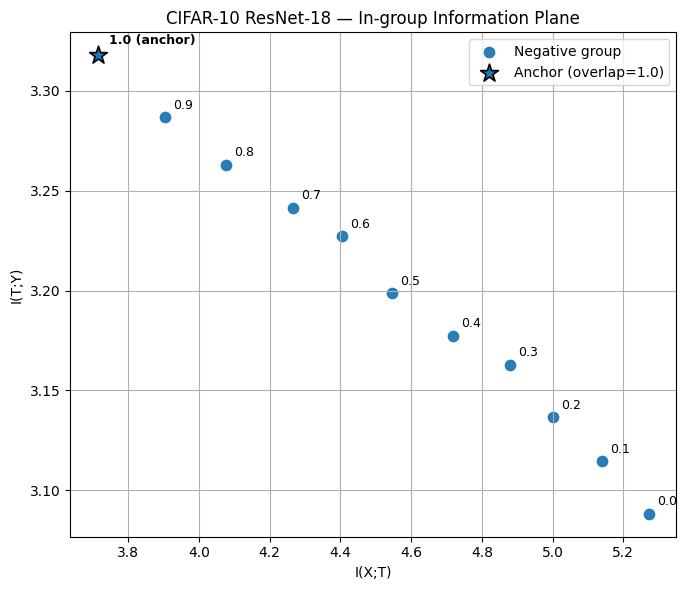

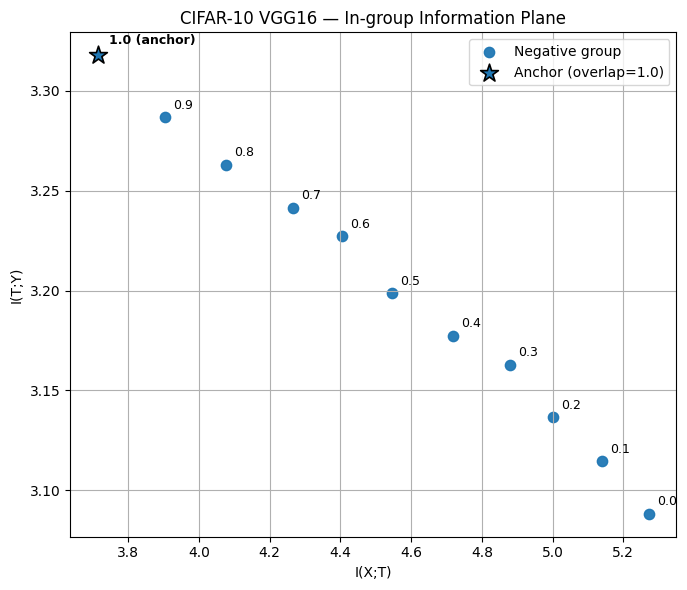

In [157]:
plot_information_plane_single_domain(
    csv_files,
    domain="in",
    title="CIFAR-10 ResNet-18 — In-group Information Plane"
)

plot_information_plane_single_domain(
    csv_files,
    domain="in",
    title="CIFAR-10 VGG16 — In-group Information Plane"
)

In [189]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")


def plot_information_plane_single_domain(
    csv_paths,
    ft_csv_paths=None,
    domain="in",                 # "in" or "out"
    title=None,
    annotate=True,
    figsize=(7, 6),
    alpha=0.95,
    anchor_rate=1.0              # anchor is the negative-group point with this overlap rate
):
    """
    Plot information plane for either in-group or out-group MI, overlaying:
      - Negative groups (independent training models)
      - Fine-tuning points (FT-LL / FT-AL / etc.)

    Anchor point:
      - Selected from negative groups by filename overlap rate == anchor_rate (e.g., 1.0)
      - Plotted with a distinctive marker to show FT is derived from it.

    Args:
        csv_paths: list of CSV file paths for negative groups
        ft_csv_paths: list of CSV file paths for fine-tuning results (optional)
        domain: "in" or "out"
        title: plot title
        annotate: annotate overlap rate next to points
        anchor_rate: overlap rate value used to select the anchor negative-group point
    """
    assert domain in ["in", "out"]

    # FT strategy markers (extend as needed)
    ft_marker_map = {
        "FT-LL": "^",
        "FT-AL": "s",
        "RT-AL": "D",
    }

    def _parse_rate_from_negative_filename(path: str) -> float:
        """
        Negative-group naming convention assumed:
          ..._<rate>_MI.csv  (rate is the second-to-last underscore token)
        Example:
          training_log_CIFAR-10_ResNet-18_42_1.0_MI.csv  -> 1.0
        """
        fname = os.path.basename(path).replace(".csv", "")
        tokens = fname.split("_")
        return float(tokens[-2])

    def _parse_rate_and_strategy_from_ft_filename(path: str):
        """
        FT naming convention assumed:
          ..._<seed>_<rate>_<strategy>_MI.csv
        Example:
          training_log_CIFAR-10_ResNet-18_42_1.0_FT-AL_MI.csv -> (1.0, "FT-AL")
        """
        fname = os.path.basename(path).replace(".csv", "")
        tokens = fname.split("_")
        rate = float(tokens[-5])
        strategy = tokens[-4]
        return rate, strategy

    # -----------------------------
    # First pass: load negative points to identify anchor
    # -----------------------------
    neg_points = []
    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)

        if domain == "in":
            ix_col = find_column(df, ["I(X;T)-In"])
            iy_col = find_column(df, ["I(T;Y)-In"])
        else:
            ix_col = find_column(df, ["I(X;T)-Out"])
            iy_col = find_column(df, ["I(T;Y)-Out"])

        ix = float(df[ix_col].iloc[0])
        iy = float(df[iy_col].iloc[0])

        rate = _parse_rate_from_negative_filename(csv_path)
        neg_points.append({"ix": ix, "iy": iy, "rate": rate, "path": csv_path})

    # Select anchor strictly by anchor_rate
    anchor_candidates = [
        i for i, p in enumerate(neg_points)
        if abs(p["rate"] - anchor_rate) < 1e-9
    ]
    if len(anchor_candidates) == 0:
        raise ValueError(
            f"No negative-group CSV found with overlap rate == {anchor_rate}. "
            f"Check your filenames or parsing rule."
        )
    
    anchor_idx = anchor_candidates[0]

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=figsize)
    legend_seen = set()

    # Keep negative groups in one color
    neg_color = "tab:blue"

    # Negative groups (including anchor)
    for i, p in enumerate(neg_points):
        ix, iy, rate = p["ix"], p["iy"], p["rate"]
        rate_str = f"{rate:.1f}"

        is_anchor = (i == anchor_idx)

        if is_anchor:
            label = "Anchor (overlap=1.0)" if "Anchor (overlap=1.0)" not in legend_seen else None
            plt.scatter(
                ix, iy,
                marker="*",
                s=180,
                alpha=1.0,
                color=neg_color,
                edgecolors="black",
                linewidths=1.2,
                label=label
            )
            if label:
                legend_seen.add(label)

            if annotate:
                plt.annotate(
                    f"{rate_str} (anchor)",
                    (ix, iy),
                    textcoords="offset points",
                    xytext=(8, 8),
                    fontsize=9,
                    fontweight="bold"
                )
        else:
            label = "Negative group" if "Negative group" not in legend_seen else None
            plt.scatter(
                ix, iy,
                marker="o",
                s=55,
                alpha=alpha,
                color=neg_color,
                label=label
            )
            if label:
                legend_seen.add(label)

            if annotate:
                plt.annotate(
                    rate_str,
                    (ix, iy),
                    textcoords="offset points",
                    xytext=(6, 6),
                    fontsize=9
                )

    # Fine-tuning groups
    if ft_csv_paths:
        for csv_path in ft_csv_paths:
            df = pd.read_csv(csv_path)

            if domain == "in":
                ix_col = find_column(df, ["I(X;T)-In"])
                iy_col = find_column(df, ["I(T;Y)-In"])
            else:
                ix_col = find_column(df, ["I(X;T)-Out"])
                iy_col = find_column(df, ["I(T;Y)-Out"])

            ix = float(df[ix_col].iloc[0])
            iy = float(df[iy_col].iloc[0])

            try:
                ft_rate, strategy = _parse_rate_and_strategy_from_ft_filename(csv_path)
                ft_rate_str = f"{ft_rate:.1f}"
            except Exception:
                strategy = "FT"
                ft_rate_str = "?"

            marker = ft_marker_map.get(strategy, "x")

            # Deduplicate legend entries per strategy
            label = strategy if strategy not in legend_seen else None
            plt.scatter(
                ix, iy,
                marker=marker,
                s=110,
                alpha=alpha,
                label=label
            )
            if label:
                legend_seen.add(label)

    # Formatting
    plt.xlabel("I(X;T)")
    plt.ylabel("I(T;Y)")
    plt.title(title or f"{domain.capitalize()}-group Information Plane")
    plt.grid(True)

    ax = plt.gca()
    ax.ticklabel_format(style="plain", axis="x", useOffset=False)
    ax.ticklabel_format(style="plain", axis="y", useOffset=False)

    plt.legend()
    plt.tight_layout()
    plt.show()


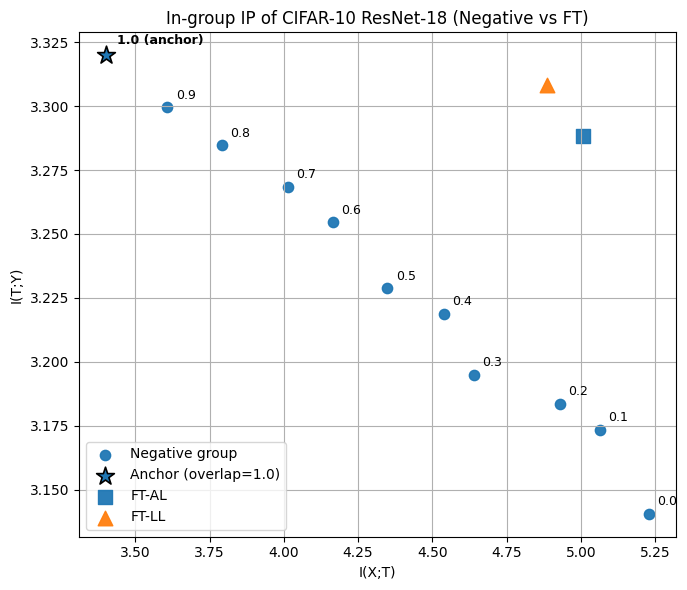

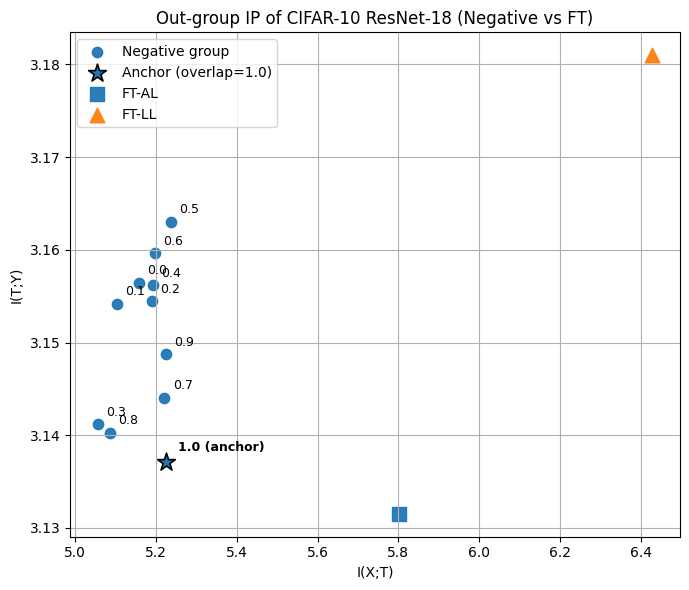

In [190]:
ft_csvs = [
    "./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_FT-AL_42_TEST_MI.csv",
    "./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_FT-LL_42_TEST_MI.csv"
]

plot_information_plane_single_domain(
    csv_paths=nega_csvs_18,
    ft_csv_paths=ft_csvs,
    domain="in",
    title="In-group IP of CIFAR-10 ResNet-18 (Negative vs FT)"
)

plot_information_plane_single_domain(
    csv_paths=nega_csvs_18,
    ft_csv_paths=ft_csvs,
    domain="out",
    title="Out-group IP of CIFAR-10 ResNet-18 (Negative vs FT)"
)

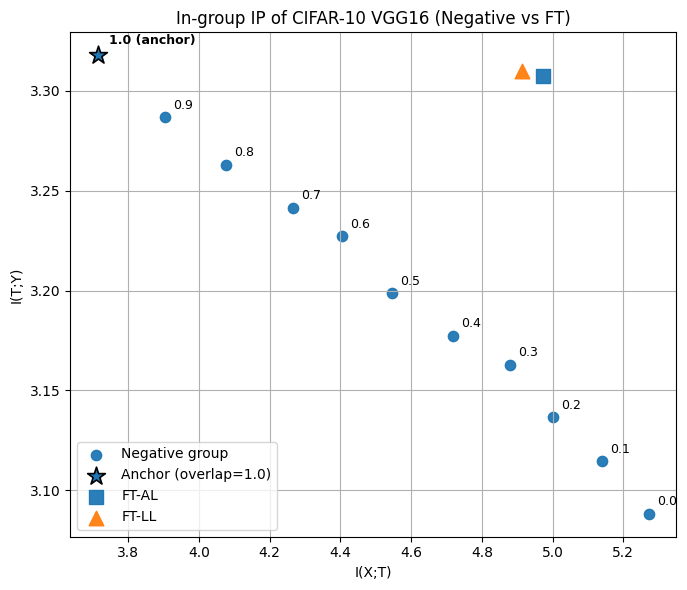

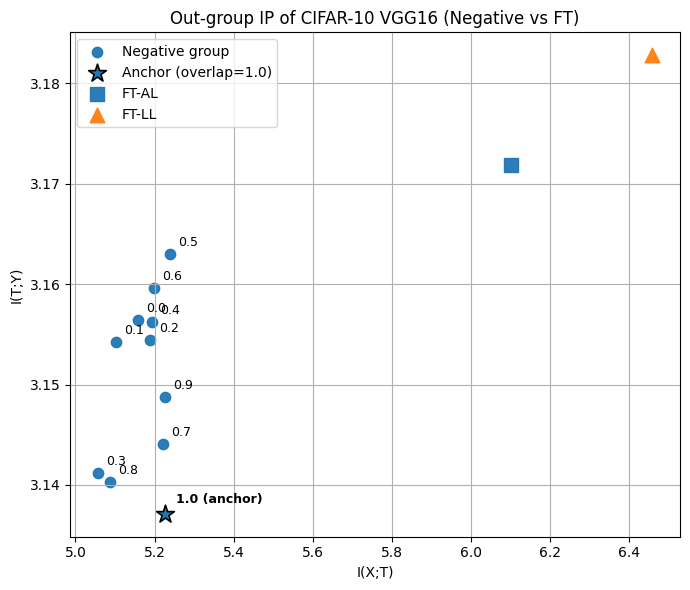

In [176]:
ft_csvs = [
    "./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_FT-AL_MI.csv",
    "./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_FT-LL_MI.csv"
]

plot_information_plane_single_domain(
    csv_paths=nega_csvs_16,
    ft_csv_paths=ft_csvs,
    domain="in",
    title="In-group IP of CIFAR-10 VGG16 (Negative vs FT)"
)

plot_information_plane_single_domain(
    csv_paths=nega_csvs_18,
    ft_csv_paths=ft_csvs,
    domain="out",
    title="Out-group IP of CIFAR-10 VGG16 (Negative vs FT)"
)

In [158]:
import numpy as np

def extract_ft_balanced_train_val(
    X,
    Y,
    total_size,
    seed=42
):
    """
    Extract two disjoint class-balanced subsets (train, val) from (X, Y),
    each of size `total_size`.

    Args:
        X (np.ndarray): shape (N, H, W, C)
        Y (np.ndarray): shape (N,)
        total_size (int): total samples for train, and total samples for val (same size)
        seed (int): random seed for reproducibility
        strict_no_overlap (bool): if True, raise if not enough samples to make disjoint splits

    Returns:
        (X_train, Y_train), (X_val, Y_val), (train_idx, val_idx)
    """
    rng = np.random.default_rng(seed)

    Y = np.asarray(Y)
    classes = np.unique(Y)
    num_classes = len(classes)

    if total_size % num_classes != 0:
        raise ValueError(
            f"total_size={total_size} not divisible by num_classes={num_classes}"
        )

    per_class = total_size // num_classes

    train_idx = []
    val_idx = []

    for c in classes:
        idx_c = np.where(Y == c)[0]
        rng.shuffle(idx_c)

        needed = 2 * per_class
        if len(idx_c) < needed:
            raise ValueError(
                f"Class {c} has only {len(idx_c)} samples; need {needed} "
                f"to build disjoint train+val (each {per_class})."
            )
            
        else:
            train_take = idx_c[:per_class]
            val_take = idx_c[per_class:per_class + per_class]

        train_idx.append(train_take)
        val_idx.append(val_take)

    train_idx = np.concatenate(train_idx)
    val_idx = np.concatenate(val_idx)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    X_train, Y_train = X[train_idx], Y[train_idx]
    X_val, Y_val = X[val_idx], Y[val_idx]

    return (X_train, Y_train), (X_val, Y_val), (train_idx, val_idx)


In [181]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")


def plot_information_plane_single_domain(
    csv_paths,
    ft_csv_paths=None,
    domain="in",                 # "in" or "out"
    title=None,
    annotate=True,
    figsize=(7, 6),
    alpha=0.95,
    anchor_rate=1.0,             # anchor is the negative-group point with this overlap rate
    annotate_ft_seed=True        # NEW: annotate each FT point with its FT seed
):
    """
    Plot information plane for either in-group or out-group MI, overlaying:
      - Negative groups (independent training models)
      - Fine-tuning points (multiple runs per FT strategy)

    Anchor point:
      - Selected from negative groups by filename overlap rate == anchor_rate
      - Plotted with a distinctive marker.

    FT filename supported:
      training_log_CIFAR-10_ResNet-18_<victimSeed>_<rate>_<strategy>_<ftSeed>_MI.csv
      e.g., training_log_CIFAR-10_ResNet-18_42_1.0_FT-AL_42_MI.csv
    """
    assert domain in ["in", "out"]

    # FT strategy markers
    ft_marker_map = {
        "FT-LL": "^",
        "FT-AL": "s",
        "RT-AL": "D",
    }

    def _parse_rate_from_negative_filename(path: str) -> float:
        """
        Negative-group naming convention assumed:
          ..._<rate>_MI.csv  (rate is the second-to-last underscore token)
        Example:
          training_log_CIFAR-10_ResNet-18_42_1.0_MI.csv -> 1.0
        """
        fname = os.path.basename(path).replace(".csv", "")
        tokens = fname.split("_")
        return float(tokens[-2])

    def _parse_ft_filename(path: str):
        """
        Supports:
          A) Old: ..._<victimSeed>_<rate>_<strategy>_MI.csv
          B) New: ..._<victimSeed>_<rate>_<strategy>_<ftSeed>_MI.csv

        Returns:
          (rate: float, strategy: str, ft_seed: int or None)
        """
        fname = os.path.basename(path).replace(".csv", "")
        tokens = fname.split("_")

        # Always ends with "..._MI"
        if tokens[-1] != "MI":
            raise ValueError(f"Unexpected FT filename (must end with _MI.csv): {fname}")

        # NEW format has an extra seed right before "MI"
        # ..._<rate>_<strategy>_<ftSeed>_MI
        # tokens[-2] should be ftSeed (int) in new format; strategy in old format.
        ft_seed = None

        # Try new format first
        try:
            ft_seed = int(tokens[-2])
            strategy = tokens[-3]
            rate = float(tokens[-4])
            return rate, strategy, ft_seed
        except Exception:
            # Fallback to old format
            strategy = tokens[-2]
            rate = float(tokens[-3])
            return rate, strategy, None

    # -----------------------------
    # Load negative points + identify anchor
    # -----------------------------
    neg_points = []
    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)

        if domain == "in":
            ix_col = find_column(df, ["I(X;T)-In"])
            iy_col = find_column(df, ["I(T;Y)-In"])
        else:
            ix_col = find_column(df, ["I(X;T)-Out"])
            iy_col = find_column(df, ["I(T;Y)-Out"])

        ix = float(df[ix_col].iloc[0])
        iy = float(df[iy_col].iloc[0])

        rate = _parse_rate_from_negative_filename(csv_path)
        neg_points.append({"ix": ix, "iy": iy, "rate": rate, "path": csv_path})

    anchor_candidates = [
        i for i, p in enumerate(neg_points)
        if abs(p["rate"] - anchor_rate) < 1e-9
    ]
    if len(anchor_candidates) == 0:
        raise ValueError(
            f"No negative-group CSV found with overlap rate == {anchor_rate}. "
            f"Check your filenames or parsing rule."
        )

    # If multiple "1.0" negatives exist, choose the one with max I(T;Y); tie -> min I(X;T)
    anchor_idx = max(
        anchor_candidates,
        key=lambda i: (neg_points[i]["iy"], -neg_points[i]["ix"])
    )

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure(figsize=figsize)
    legend_seen = set()

    neg_color = "tab:blue"

    # Negative groups
    for i, p in enumerate(neg_points):
        ix, iy, rate = p["ix"], p["iy"], p["rate"]
        rate_str = f"{rate:.1f}"

        if i == anchor_idx:
            label = "Anchor (overlap=1.0)" if "Anchor (overlap=1.0)" not in legend_seen else None
            plt.scatter(
                ix, iy,
                marker="*",
                s=180,
                alpha=1.0,
                color=neg_color,
                edgecolors="black",
                linewidths=1.2,
                label=label
            )
            if label:
                legend_seen.add(label)

            if annotate:
                plt.annotate(
                    f"{rate_str} (anchor)",
                    (ix, iy),
                    textcoords="offset points",
                    xytext=(8, 8),
                    fontsize=9,
                    fontweight="bold"
                )
        else:
            label = "Negative group" if "Negative group" not in legend_seen else None
            plt.scatter(
                ix, iy,
                marker="o",
                s=55,
                alpha=alpha,
                color=neg_color,
                label=label
            )
            if label:
                legend_seen.add(label)

            if annotate:
                plt.annotate(
                    rate_str,
                    (ix, iy),
                    textcoords="offset points",
                    xytext=(6, 6),
                    fontsize=9
                )

    # -----------------------------
    # Fine-tuning groups (multiple runs)
    # -----------------------------
    if ft_csv_paths:
        for csv_path in ft_csv_paths:
            df = pd.read_csv(csv_path)

            if domain == "in":
                ix_col = find_column(df, ["I(X;T)-In"])
                iy_col = find_column(df, ["I(T;Y)-In"])
            else:
                ix_col = find_column(df, ["I(X;T)-Out"])
                iy_col = find_column(df, ["I(T;Y)-Out"])

            ix = float(df[ix_col].iloc[0])
            iy = float(df[iy_col].iloc[0])

            try:
                ft_rate, strategy, ft_seed = _parse_ft_filename(csv_path)
            except Exception:
                ft_rate, strategy, ft_seed = None, "FT", None

            marker = ft_marker_map.get(strategy, "x")

            # Deduplicate legend entries per strategy
            label = strategy if strategy not in legend_seen else None
            plt.scatter(
                ix, iy,
                marker=marker,
                s=110,
                alpha=alpha,
                label=label
            )
            if label:
                legend_seen.add(label)

            # Optional annotation for FT points: show ft_seed (and/or rate)
            if annotate and annotate_ft_seed:
                seed_str = f"s{ft_seed}" if ft_seed is not None else ""
                plt.annotate(
                    seed_str,
                    (ix, iy),
                    textcoords="offset points",
                    xytext=(6, -10),
                    fontsize=9
                )

    # Formatting
    plt.xlabel("I(X;T)")
    plt.ylabel("I(T;Y)")
    plt.title(title or f"{domain.capitalize()}-group Information Plane")
    plt.grid(True)

    ax = plt.gca()
    ax.ticklabel_format(style="plain", axis="x", useOffset=False)
    ax.ticklabel_format(style="plain", axis="y", useOffset=False)

    plt.legend()
    plt.tight_layout()
    plt.show()


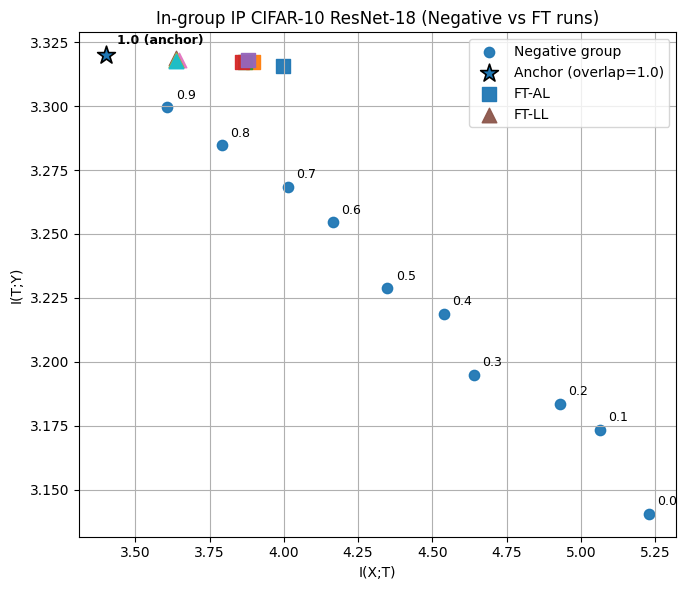

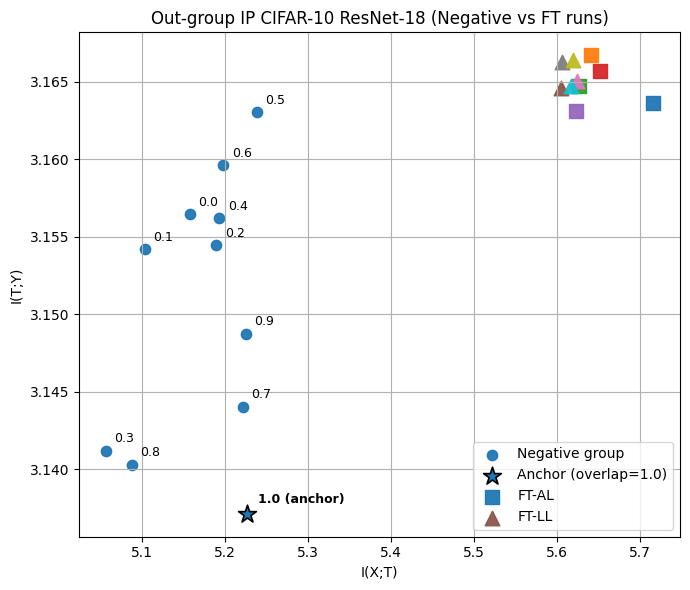

In [186]:
import glob

ft_csv_paths = glob.glob(
    "./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_FT-AL_*_MI.csv"
) + glob.glob(
    "./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_FT-LL_*_MI.csv"
)

plot_information_plane_single_domain(
    csv_paths=nega_csvs_18,
    ft_csv_paths=ft_csv_paths,
    domain="in",
    title="In-group IP CIFAR-10 ResNet-18 (Negative vs FT runs)",
    annotate=True,
    annotate_ft_seed=False
)

plot_information_plane_single_domain(
    csv_paths=nega_csvs_18,
    ft_csv_paths=ft_csv_paths,
    domain="out",
    title="Out-group IP CIFAR-10 ResNet-18 (Negative vs FT runs)",
    annotate=True,
    annotate_ft_seed=False
)



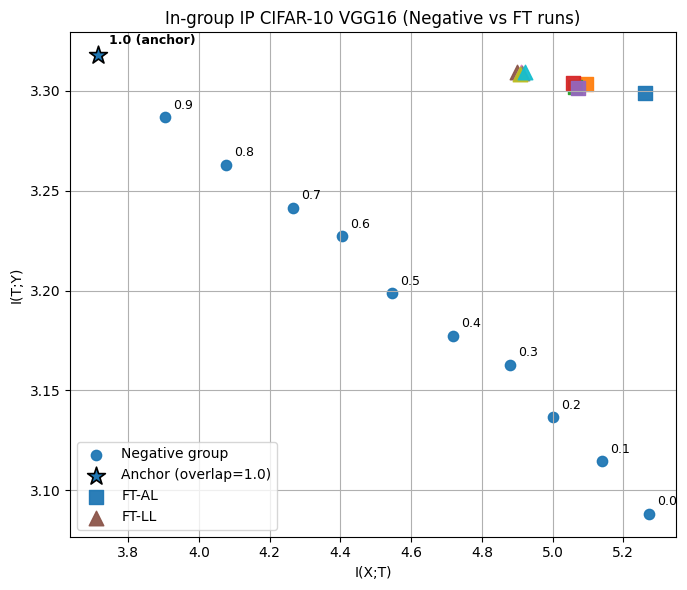

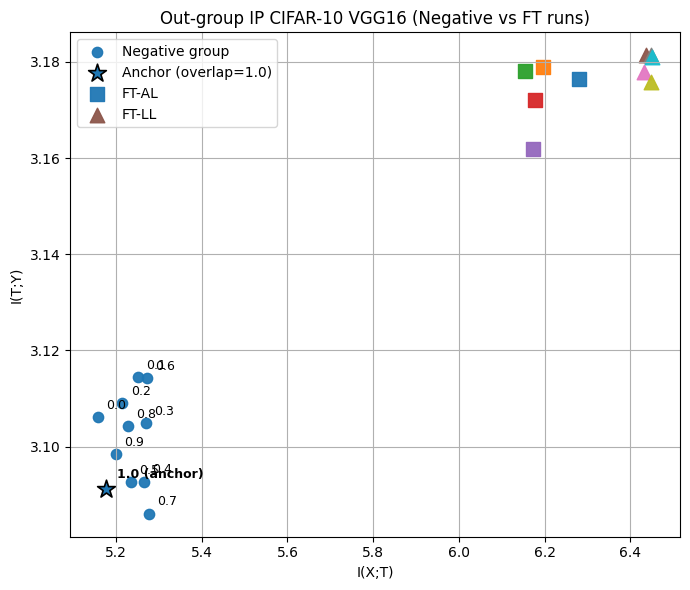

In [187]:
import glob

ft_csv_paths = glob.glob(
    "./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_FT-AL_*_MI.csv"
) + glob.glob(
    "./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_FT-LL_*_MI.csv"
)

plot_information_plane_single_domain(
    csv_paths=nega_csvs_16,
    ft_csv_paths=ft_csv_paths,
    domain="in",
    title="In-group IP CIFAR-10 VGG16 (Negative vs FT runs)",
    annotate=True,
    annotate_ft_seed=False
)

plot_information_plane_single_domain(
    csv_paths=nega_csvs_16,
    ft_csv_paths=ft_csv_paths,
    domain="out",
    title="Out-group IP CIFAR-10 VGG16 (Negative vs FT runs)",
    annotate=True,
    annotate_ft_seed=False
)



In [160]:
(X_tr, Y_tr), (X_va, Y_va), (idx_tr, idx_va) = extract_ft_balanced_train_val(
    X, Y,
    total_size=10_000,
    seed=42
)

print(X_tr.shape, Y_tr.shape)
print(X_va.shape, Y_va.shape)

# sanity checks
print("Train class counts:", np.bincount(Y_tr))
print("Val class counts:", np.bincount(Y_va))
print("Overlap:", len(set(idx_tr).intersection(set(idx_va))))


(10000, 32, 32, 3) (10000,)
(10000, 32, 32, 3) (10000,)
Train class counts: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
Val class counts: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]
Overlap: 0


In [167]:
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.datasets import CIFAR10


class CIFAR10Dataset(Dataset):
    def __init__(self, normalization="cifar10", loading="torchvision", 
                 root_dir="./data", build_dataset=True):
        super().__init__()
        self.train_set = None
        self.test_set = None
        self.root_dir = root_dir
        self.loading = loading
        self.normalization = normalization
        self.mean = self.set_normalization(normalization)["mean"]
        self.std = self.set_normalization(normalization)["std"]

        self.train_transfroms = transforms.Compose(
                [
                    transforms.RandomCrop(32, padding=4),
                    transforms.RandomHorizontalFlip(),
                    transforms.ToTensor(),
                    transforms.Normalize(self.mean, self.std),
                ]
            )
        
        self.test_transforms = transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.Normalize(self.mean, self.std),
                ]
            )

        self.train_set = None
        self.test_set = None
        self.in_sample_set = None

        if build_dataset:
            self._build_datasets()

    def _build_datasets(self):
        self.train_set = self.get_dataset(
            train=True,
            transform=self.train_transfroms
        )
        self.test_set = self.get_dataset(
            train=False,
            transform=self.test_transforms
        )
        self.in_sample_set = self.get_dataset(
            train=True,
            transform=self.test_transforms
        )


    def set_normalization(self, normalization):
        # Image classification on the CIFAR10 dataset - Albumentations Documentation
        # https://albumentations.ai/docs/autoalbument/examples/cifar10/
        if normalization == "cifar10":
            mean = (0.4914, 0.4822, 0.4465)
            std = (0.2471, 0.2435, 0.2616)
        elif normalization == "imagenet":
            # ImageNet - torchbench Docs https://paperswithcode.github.io/torchbench/imagenet/
            mean = (0.485, 0.456, 0.406)
            std = (0.229, 0.224, 0.225)
        else:
            raise NotImplementedError
        return {"mean": mean, "std": std}

    def get_dataset(self, train, transform, download=True):
        if self.loading == "torchvision":
            dataset = CIFAR10(
                root=self.root_dir,
                train=train,
                transform=transform,
                download=download,
            )
        elif self.loading == "custom":
            raise NotImplementedError
        else:
            raise NotImplementedError
        return dataset
    

import torch
import numpy as np
from PIL import Image

class NumpyImageDataset(Dataset):
    """
    CIFAR-compatible dataset backed by numpy arrays.
    """
    def __init__(self, X, Y, transform=None):
        assert isinstance(X, np.ndarray)
        assert isinstance(Y, np.ndarray)
        assert X.shape[0] == Y.shape[0]

        self.X = X
        self.Y = Y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]  # (H, W, C), uint8
        label = int(self.Y[idx])

        # Convert numpy array to PIL Image (torchvision-native behavior)
        img = Image.fromarray(img)

        if self.transform is not None:
            img = self.transform(img)

        return img, label
    
    
class CIFAR10PseudoLabelDataset(CIFAR10Dataset):
    """
    CIFAR10-compatible dataset using pseudo-labeled auxiliary data
    (e.g., TinyImages / ImageNet-derived).
    """

    def __init__(self, X, Y, normalization="cifar10"):
        """
        Args:
            X (np.ndarray): shape (N, 32, 32, 3)
            Y (np.ndarray): shape (N,)
        """
        # Initialize parent to get normalization + transforms
        super().__init__(
            normalization=normalization,
            loading="torchvision",
            root_dir=None,
            build_dataset=False
        )

        # Override datasets with numpy-backed versions
        self.train_set = NumpyImageDataset(
            X=X,
            Y=Y,
            transform=self.train_transfroms,
        )

        # We intentionally do NOT define a test_set here
        self.test_set = None

        # In-sample version without augmentation (optional, useful for MI)
        self.in_sample_set = NumpyImageDataset(
            X=X,
            Y=Y,
            transform=self.test_transforms,
        )




In [173]:
ft_data_val = CIFAR10PseudoLabelDataset(X=X_va, Y=Y_va, normalization="cifar10")

from torch.utils.data import Subset, DataLoader
test_loader = DataLoader(ft_data_val.in_sample_set, batch_size=128, shuffle=False, num_workers=8, persistent_workers=True, pin_memory=True)

In [165]:
def load_last_checkpoint(model_dir: Path):
    """
    Load the most recent .pth checkpoint in a model directory.
    Returns the checkpoint path or None if not found.
    """
    ckpt_files = sorted(model_dir.glob("*.pth"), key=os.path.getmtime)
    if not ckpt_files:
        return None
    last_ckpt = ckpt_files[-1]  # the newest one
    print(f"[📦] Loading last checkpoint: {last_ckpt.name}")
    return last_ckpt



In [174]:
a = 5

def fun1(a):
    a += 5

    print("addition")

fun1(a)
print(a)

addition
5


In [220]:
ix_in, iy_in = read_mi_point("./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_FT-AL_42_MI.csv", "in")
ix_out, iy_out = read_mi_point("./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_FT-AL_42_MI.csv", "out")

print(f"in group mi is {ix_in} and {iy_in}.")
print(f"out group mi is {ix_out} and {iy_out}.")

in group mi is 3.9987988471984863 and 3.3155341148376465.
out group mi is 5.715355396270752 and 3.163648128509521.


In [221]:
path = "./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_FT-AL_42_MI.csv"
fname = os.path.basename(path).replace(".csv", "")
tokens = fname.split("_")

In [222]:
fname

'training_log_CIFAR-10_ResNet-18_42_1.0_FT-AL_42_MI'

In [225]:
tokens[-2]

'42'

In [266]:
import os
from dataclasses import dataclass
from typing import Callable, List, Optional, Dict, Any, Tuple

import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Utilities
# -----------------------------
def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")


def read_mi_point(csv_path: str, domain: str) -> Tuple[float, float]:
    """
    Read a single MI coordinate (ix, iy) from a CSV file.
    Assumes the MI values are stored in the first row.
    """
    df = pd.read_csv(csv_path)

    if domain == "in":
        ix_col = find_column(df, ["I(X;T)-In"])
        iy_col = find_column(df, ["I(T;Y)-In"])
    elif domain == "out":
        ix_col = find_column(df, ["I(X;T)-Out"])
        iy_col = find_column(df, ["I(T;Y)-Out"])
    else:
        raise ValueError("domain must be 'in' or 'out'")

    ix = float(df[ix_col].iloc[0])
    iy = float(df[iy_col].iloc[0])
    return ix, iy


# -----------------------------
# Group specification
# -----------------------------
@dataclass
class GroupSpec:
    """
    Defines how to plot one "group" of points.

    - csv_paths: list of files for that group
    - label: legend label for this group
    - style: scatter style kwargs (marker, color, s, alpha, etc.)
    - annotate: whether to annotate each point
    - annotate_text_fn: function that produces text from csv_path (and optionally ix, iy)
    """
    label: str
    csv_paths: List[str]
    style: Dict[str, Any]

    domain:str = "in"

    annotate: bool = False
    annotate_text_fn: Optional[Callable[[str], str]] = None
    annotate_kwargs: Optional[Dict[str, Any]] = None  # e.g., xytext, fontsize


# -----------------------------
# Anchor specification
# -----------------------------
@dataclass
class AnchorSpec:
    """
    Defines how to pick and plot an anchor point from one GroupSpec.

    - group_label: which group to search in (by GroupSpec.label)
    - select_fn: function that selects an anchor index given list of points
    - style: scatter style override for the anchor point
    - annotate_text: optional anchor annotation
    """
    group_label: str
    select_fn: Callable[[List[Dict[str, Any]]], int]
    style: Dict[str, Any]
    annotate_text: Optional[str] = None
    annotate_kwargs: Optional[Dict[str, Any]] = None


# -----------------------------
# Core plotting function
# -----------------------------
def plot_information_plane(
    groups: List[GroupSpec],
    title: Optional[str] = None,
    figsize: Tuple[int, int] = (7, 6),
    grid: bool = True,
    plain_ticks: bool = True,
    anchor: Optional[AnchorSpec] = None,
):
    """
    Modular MI plane plotter. Plots any number of groups, each defined by GroupSpec.

    Args:
        groups: list of GroupSpec
        domain: "in" or "out"
        title: plot title
        figsize: figure size
        anchor: optional AnchorSpec to highlight one anchor point
    """
    # assert domain in ["in", "out"]

    # Load all points for all groups (so anchor selection can be done cleanly)
    all_group_points: Dict[str, List[Dict[str, Any]]] = {}

    for g in groups:
        pts = []
        for p in g.csv_paths:
            ix, iy = read_mi_point(p, g.domain)
            pts.append({"path": p, "ix": ix, "iy": iy})
        all_group_points[g.label] = pts

    # Determine anchor index if requested
    anchor_idx = None
    if anchor is not None:
        if anchor.group_label not in all_group_points:
            raise ValueError(
                f"AnchorSpec.group_label='{anchor.group_label}' not found in groups."
            )
        anchor_idx = anchor.select_fn(all_group_points[anchor.group_label])

    # Plot
    plt.figure(figsize=figsize)
    legend_seen = set()

    for g in groups:
        pts = all_group_points[g.label]
        for i, pt in enumerate(pts):
            is_anchor = (
                anchor is not None
                and g.label == anchor.group_label
                and anchor_idx is not None
                and i == anchor_idx
            )

            # Scatter style
            style = dict(g.style)  # copy
            label = None

            if is_anchor:
                # Override with anchor style
                style.update(anchor.style)
                label = anchor.style.get("label", None)
                if label is None:
                    label = "Anchor"
            else:
                label = g.label

            # Deduplicate legend entries
            if label in legend_seen:
                label_for_scatter = None
            else:
                label_for_scatter = label
                legend_seen.add(label)

            plt.scatter(pt["ix"], pt["iy"], label=label_for_scatter, **style)

            # Annotation
            if is_anchor and anchor.annotate_text:
                akw = anchor.annotate_kwargs or {"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
                plt.annotate(
                    anchor.annotate_text,
                    (pt["ix"], pt["iy"]),
                    textcoords="offset points",
                    **akw
                )
            elif g.annotate and g.annotate_text_fn is not None:
                text = g.annotate_text_fn(pt["path"])
                akw = g.annotate_kwargs or {"xytext": (6, 6), "fontsize": 9}
                plt.annotate(
                    text,
                    (pt["ix"], pt["iy"]),
                    textcoords="offset points",
                    **akw
                )

    # Formatting
    plt.xlabel("I(X;T)")
    plt.ylabel("I(T;Y)")
    plt.title(title)

    if grid:
        plt.grid(True)

    if plain_ticks:
        ax = plt.gca()
        ax.ticklabel_format(style="plain", axis="x", useOffset=False)
        ax.ticklabel_format(style="plain", axis="y", useOffset=False)

    plt.legend()
    plt.tight_layout()
    plt.show()


def parse_neg_overlapping_rate(path: str) -> str:
    # ..._<rate>_MI.csv (rate is second-to-last token)
    fname = os.path.basename(path).replace(".csv", "")
    tokens = fname.split("_")
    return f"{float(tokens[-2]):.1f}"

def parse_neg_super_samples(path: str) -> str:
    # ..._<rate>_MI.csv (rate is second-to-last token)
    fname = os.path.basename(path).replace(".csv", "")
    tokens = fname.split("_")
    return tokens[-2]

def parse_ft_seed_or_strategy(path: str) -> str:
    # example: ..._1.0_FT-AL_42_MI.csv  -> annotate "s42"
    fname = os.path.basename(path).replace(".csv", "")
    tokens = fname.split("_")
    # tokens[-1] == "MI"
    ft_seed = tokens[-2]
    return f"s{ft_seed}"

def select_anchor_by_rate_1p0(points: List[Dict[str, Any]]) -> int:
    # choose the first point whose filename rate == 1.0; if multiple, pick max I(T;Y)
    candidates = []
    for i, pt in enumerate(points):
        r = float(os.path.basename(pt["path"]).replace(".csv", "").split("_")[-2])
        if abs(r - 1.0) < 1e-9:
            candidates.append(i)
    if not candidates:
        raise ValueError("No negative point found with rate=1.0 for anchor selection.")
    # choose highest iy (and if tie, smallest ix)
    return max(candidates, key=lambda i: (points[i]["iy"], -points[i]["ix"]))



In [299]:
def generate_csv_paths(file_dir, dataset, model, victim_seed, rate_ls):
    csv_ls = []
    for rate in rate_ls:
        csv_name = f"training_log_{dataset}_{model}_{victim_seed}_{rate}_MI.csv"
        csv_ls.append(file_dir + csv_name)

    return csv_ls

DATASET = ["CIFAR-10"]
MODEL = ["ResNet-18"]#, "VGG16"]
VICTIM_SEED = range(42, 43)

OVERLAPPING = np.linspace(0,1,11)
SUPER = range(5000, 25001, 5000)

for d in DATASET:
    for m in MODEL:
        for s in VICTIM_SEED:
            neg_group1 = generate_csv_paths("./saved_logs/normal_nega/MI/", d, m, s, OVERLAPPING)
            neg_group2 = generate_csv_paths("./saved_logs/normal_nega/MI/", d, m, s, SUPER)
        
    

In [268]:
neg_group1

['./saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.0_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.1_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.2_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.30000000000000004_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.4_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.5_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.6000000000000001_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.7000000000000001_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.8_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_0.9_MI.csv',
 './saved_logs/normal_nega/MI/training_log_CIFAR-10_ResNet-18_42_1.0_MI.csv']

In [279]:
neg_in_group1_spec = GroupSpec(
    label="Negative Group 1 (In)",
    csv_paths=neg_group1,
    domain = "in",
    style={"marker": "o", "color": "tab:blue", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg_in_group2_spec = GroupSpec(
    label="Negative Group 2 (In)",
    csv_paths=neg_group2,
    domain = "in",
    style={"marker": "o", "color": "tab:purple", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_neg_super_samples,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg_out_group1_spec = GroupSpec(
    label="Negative Group 1 (Out)",
    csv_paths=neg_group1,
    domain = "out",
    style={"marker": "o", "color": "tab:orange", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_overlapping_rate,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

neg_out_group2_spec = GroupSpec(
    label="Negative Group 2 (Out)",
    csv_paths=neg_group2,
    domain = "out",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=True,
    annotate_text_fn=parse_neg_super_samples,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

anchor_spec = AnchorSpec(
    group_label="Negative Group 1 (In)",
    select_fn=select_anchor_by_rate_1p0,
    style={"marker": "*", "s": 180, "alpha": 1.0, "color": "tab:blue",
           "edgecolors": "black", "linewidths": 1.2},
    annotate_text="1.0 (anchor)",
    annotate_kwargs={"xytext": (8, 8), "fontsize": 9, "fontweight": "bold"}
)



In [270]:
print(type(neg_group1_spec.csv_paths))
print(type(neg_group2_spec.csv_paths))


<class 'list'>
<class 'list'>


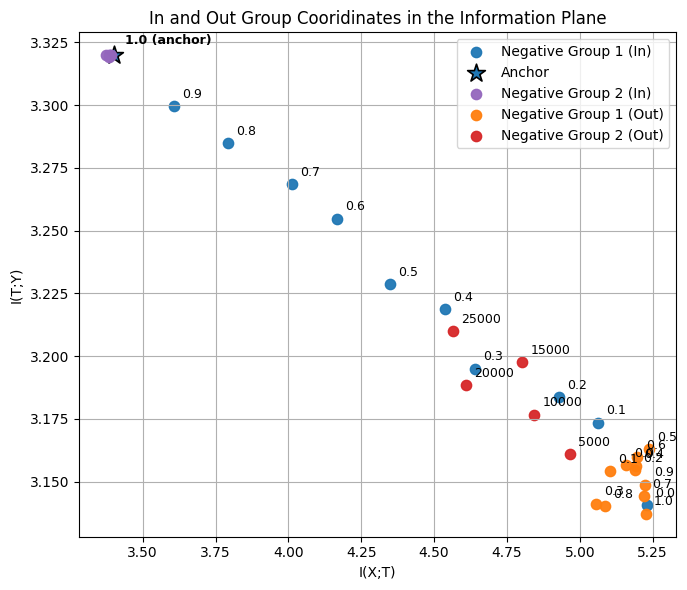

In [271]:
plot_information_plane(
    groups=[neg_in_group1_spec, neg_in_group2_spec, neg_out_group1_spec, neg_out_group2_spec],
    title="In and Out Group Cooridinates in the Information Plane",
    anchor=anchor_spec
)

In [274]:
ft1_paths = ["./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_FT-AL_42_TEST_MI.csv"]
ft2_paths = ["./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_FT-LL_42_TEST_MI.csv"]

In [284]:
ft1_in_group_spec = GroupSpec(
    label="FT-AL (In)",
    csv_paths=ft1_paths,
    domain = "in",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

ft2_in_group_spec = GroupSpec(
    label="FT-LL (In)",
    csv_paths=ft2_paths,
    domain = "in",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

ft1_out_group_spec = GroupSpec(
    label="FT-AL (Out)",
    csv_paths=ft1_paths,
    domain = "out",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

ft2_out_group_spec = GroupSpec(
    label="FT-LL (Out)",
    csv_paths=ft2_paths,
    domain = "out",
    style={"marker": "o", "color": "tab:pink", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

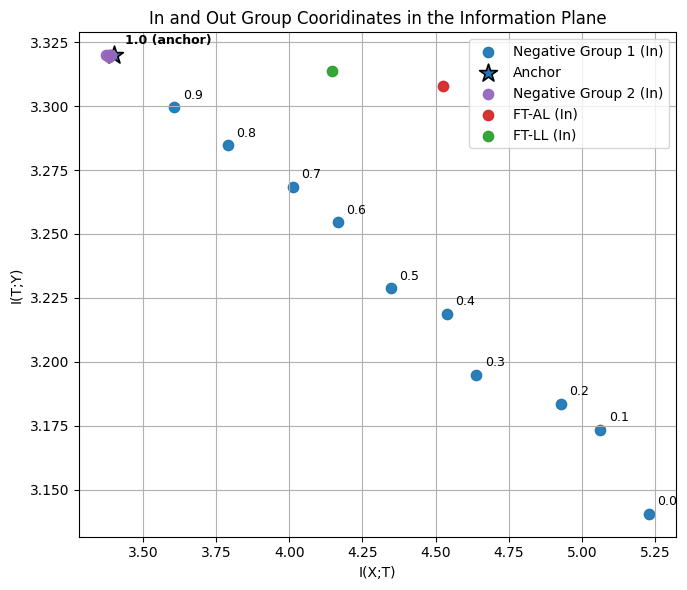

In [282]:
plot_information_plane(
    groups=[neg_in_group1_spec, neg_in_group2_spec, ft1_in_group_spec, ft2_in_group_spec],
    title="In and Out Group Cooridinates in the Information Plane",
    anchor=anchor_spec
)

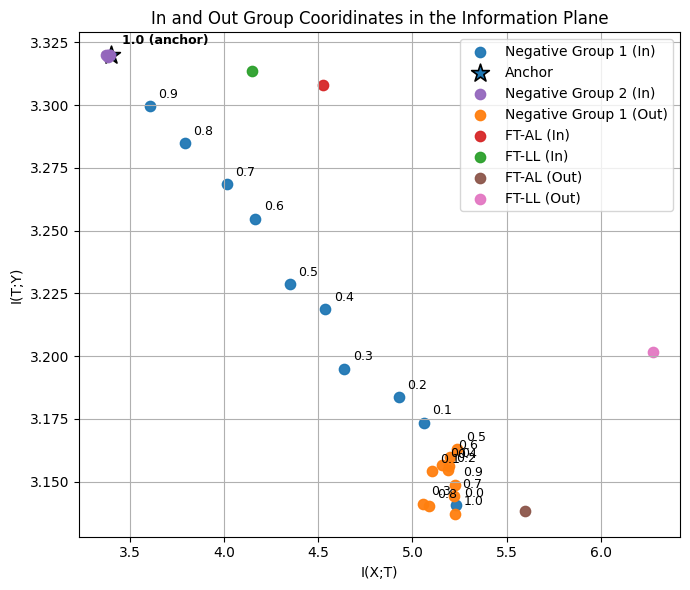

In [285]:
plot_information_plane(
    groups=[neg_in_group1_spec, neg_in_group2_spec, neg_out_group1_spec, ft1_in_group_spec, ft2_in_group_spec, 
            ft1_out_group_spec, ft2_out_group_spec],
    title="In and Out Group Cooridinates in the Information Plane",
    anchor=anchor_spec
) # 25 epochs used for fine-tuning

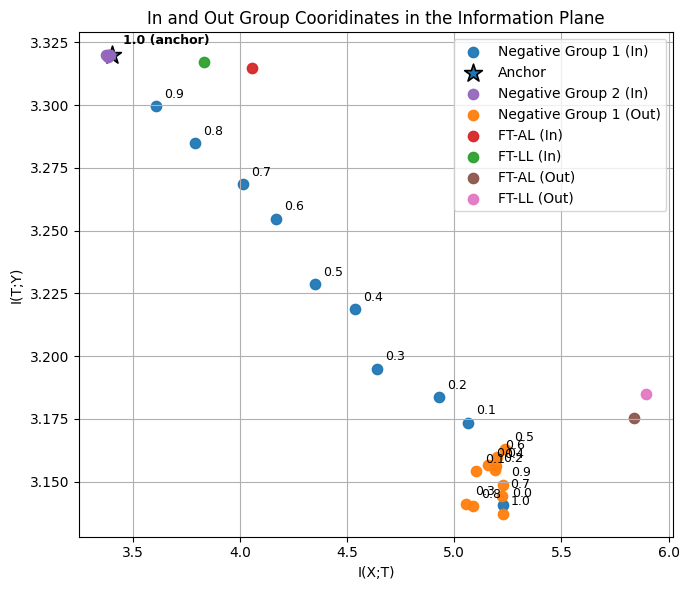

In [287]:
ft1_paths = ["./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_FT-AL_42_TESTepoch=15_MI.csv"]
ft2_paths = ["./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_FT-LL_42_TESTepoch=15_MI.csv"]

ft1_in_group_spec = GroupSpec(
    label="FT-AL (In)",
    csv_paths=ft1_paths,
    domain = "in",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

ft2_in_group_spec = GroupSpec(
    label="FT-LL (In)",
    csv_paths=ft2_paths,
    domain = "in",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

ft1_out_group_spec = GroupSpec(
    label="FT-AL (Out)",
    csv_paths=ft1_paths,
    domain = "out",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

ft2_out_group_spec = GroupSpec(
    label="FT-LL (Out)",
    csv_paths=ft2_paths,
    domain = "out",
    style={"marker": "o", "color": "tab:pink", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

plot_information_plane(
    groups=[neg_in_group1_spec, neg_in_group2_spec, neg_out_group1_spec, ft1_in_group_spec, ft2_in_group_spec, 
            ft1_out_group_spec, ft2_out_group_spec],
    title="In and Out Group Cooridinates in the Information Plane",
    anchor=anchor_spec
) # 15 epochs used for fine-tuning

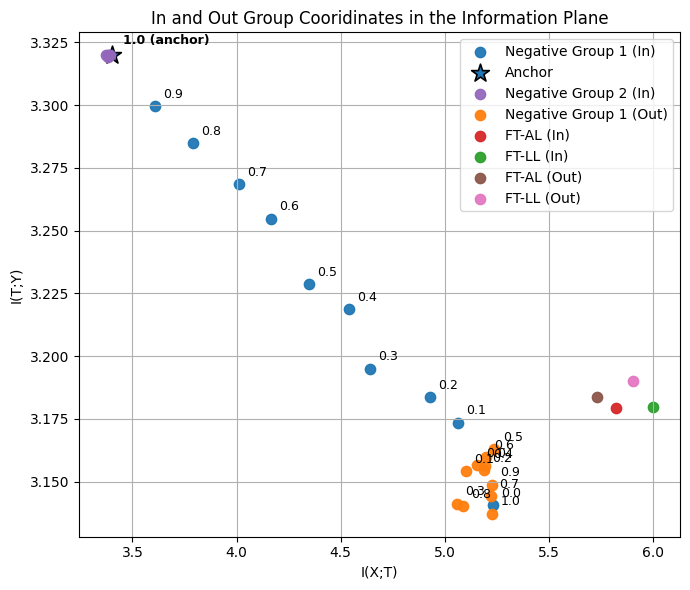

In [288]:
ft1_paths = ["./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_0.0_FT-AL_42_TESTepoch=15_MI.csv"]
ft2_paths = ["./saved_logs/fine_tune_new1/MI/training_log_CIFAR-10_ResNet-18_42_0.0_FT-LL_42_TESTepoch=15_MI.csv"]

ft1_in_group_spec = GroupSpec(
    label="FT-AL (In)",
    csv_paths=ft1_paths,
    domain = "in",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

ft2_in_group_spec = GroupSpec(
    label="FT-LL (In)",
    csv_paths=ft2_paths,
    domain = "in",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

ft1_out_group_spec = GroupSpec(
    label="FT-AL (Out)",
    csv_paths=ft1_paths,
    domain = "out",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

ft2_out_group_spec = GroupSpec(
    label="FT-LL (Out)",
    csv_paths=ft2_paths,
    domain = "out",
    style={"marker": "o", "color": "tab:pink", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

plot_information_plane(
    groups=[neg_in_group1_spec, neg_in_group2_spec, neg_out_group1_spec, ft1_in_group_spec, ft2_in_group_spec, 
            ft1_out_group_spec, ft2_out_group_spec],
    title="In and Out Group Cooridinates in the Information Plane",
    anchor=anchor_spec
) # 15 epochs used for fine-tuning

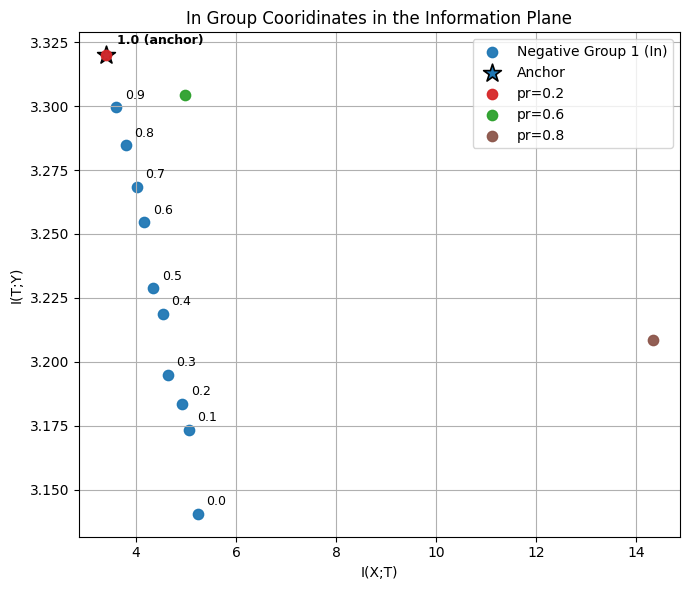

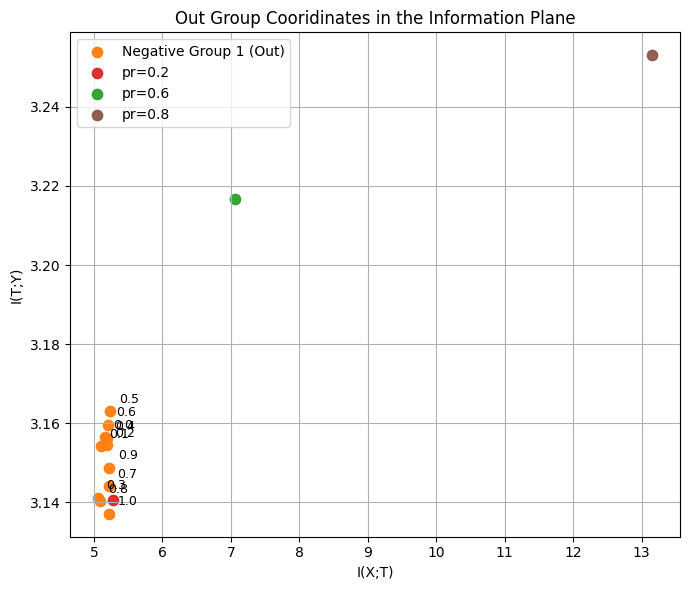

In [297]:
prune_paths = ["./saved_logs/prune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_0.2_MI.csv",
              "./saved_logs/prune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_0.6_MI.csv",
              "./saved_logs/prune_new1/MI/training_log_CIFAR-10_ResNet-18_42_1.0_0.8_MI.csv"]

pr02_in_group_spec = GroupSpec(
    label="pr=0.2",
    csv_paths=[prune_paths[0]],
    domain = "in",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr06_in_group_spec = GroupSpec(
    label="pr=0.6",
    csv_paths=[prune_paths[1]],
    domain = "in",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr08_in_group_spec = GroupSpec(
    label="pr=0.8",
    csv_paths=[prune_paths[2]],
    domain = "in",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr02_out_group_spec = GroupSpec(
    label="pr=0.2",
    csv_paths=[prune_paths[0]],
    domain = "out",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr06_out_group_spec = GroupSpec(
    label="pr=0.6",
    csv_paths=[prune_paths[1]],
    domain = "out",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr08_out_group_spec = GroupSpec(
    label="pr=0.8",
    csv_paths=[prune_paths[2]],
    domain = "out",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

plot_information_plane(
    groups=[neg_in_group1_spec, pr02_in_group_spec, pr06_in_group_spec, pr08_in_group_spec],
    title="In Group Cooridinates in the Information Plane",
    anchor=anchor_spec
) 

plot_information_plane(
    groups=[neg_out_group1_spec, pr02_out_group_spec, pr06_out_group_spec, pr08_out_group_spec],
    title="Out Group Cooridinates in the Information Plane",
    anchor=None
) 

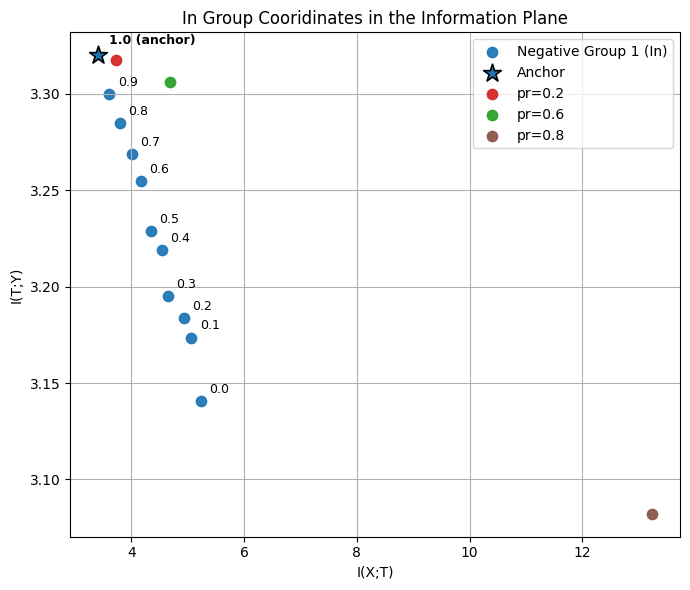

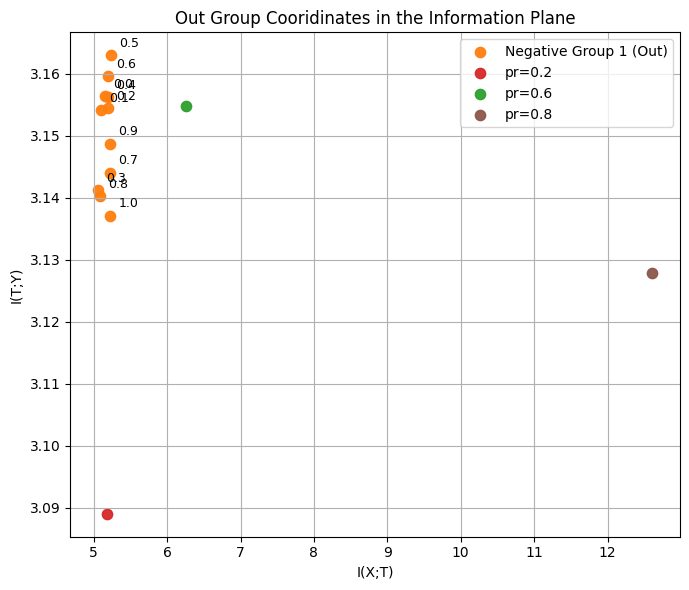

In [298]:
prune_paths = ["./saved_logs/prune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_0.2_MI.csv",
              "./saved_logs/prune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_0.6_MI.csv",
              "./saved_logs/prune_new1/MI/training_log_CIFAR-10_VGG16_42_1.0_0.8_MI.csv"]

pr02_in_group_spec = GroupSpec(
    label="pr=0.2",
    csv_paths=[prune_paths[0]],
    domain = "in",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr06_in_group_spec = GroupSpec(
    label="pr=0.6",
    csv_paths=[prune_paths[1]],
    domain = "in",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr08_in_group_spec = GroupSpec(
    label="pr=0.8",
    csv_paths=[prune_paths[2]],
    domain = "in",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr02_out_group_spec = GroupSpec(
    label="pr=0.2",
    csv_paths=[prune_paths[0]],
    domain = "out",
    style={"marker": "o", "color": "tab:red", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr06_out_group_spec = GroupSpec(
    label="pr=0.6",
    csv_paths=[prune_paths[1]],
    domain = "out",
    style={"marker": "o", "color": "tab:green", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

pr08_out_group_spec = GroupSpec(
    label="pr=0.8",
    csv_paths=[prune_paths[2]],
    domain = "out",
    style={"marker": "o", "color": "tab:brown", "s": 55, "alpha": 0.95},
    annotate=False,
    annotate_text_fn=parse_ft_seed_or_strategy,
    annotate_kwargs={"xytext": (6, 6), "fontsize": 9}
)

plot_information_plane(
    groups=[neg_in_group1_spec, pr02_in_group_spec, pr06_in_group_spec, pr08_in_group_spec],
    title="In Group Cooridinates in the Information Plane",
    anchor=anchor_spec
) 

plot_information_plane(
    groups=[neg_out_group1_spec, pr02_out_group_spec, pr06_out_group_spec, pr08_out_group_spec],
    title="Out Group Cooridinates in the Information Plane",
    anchor=None
) 

In [286]:
import os
import re
from pathlib import Path
from typing import Optional, Union


def load_checkpoint(
    model_dir: Path,
    epoch: Optional[Union[int, str]] = None,
    pattern: str = r"(?:epoch|ep)[-_]?(\d+)",  # matches "epoch_12", "ep-12", etc.
) -> Optional[Path]:
    """
    Select a .pth checkpoint from a directory.

    Args:
        model_dir: directory containing .pth checkpoints
        epoch:
            - None or "latest": pick newest by mtime (your current behavior)
            - int: pick checkpoint whose filename contains that epoch number (best-effort)
        pattern: regex used to extract epoch from filename

    Returns:
        Path to selected checkpoint, or None if not found / no match.
    """
    ckpt_files = list(model_dir.glob("*.pth"))
    if not ckpt_files:
        return None

    # Default: latest by modification time
    if epoch is None or (isinstance(epoch, str) and epoch.lower() in {"latest", "newest", "last"}):
        return max(ckpt_files, key=lambda p: p.stat().st_mtime)

    # Epoch-based selection
    if not isinstance(epoch, int) or epoch < 0:
        raise ValueError(f"epoch must be a non-negative int or None/'latest', got: {epoch}")

    # Build epoch -> candidates mapping
    epoch_candidates = []
    for p in ckpt_files:
        m = re.search(pattern, p.stem)
        if m:
            e = int(m.group(1))
            if e == epoch:
                epoch_candidates.append(p)

    if not epoch_candidates:
        return None

    # If multiple matches, pick the newest among them
    return max(epoch_candidates, key=lambda p: p.stat().st_mtime)


model_path = "./saved_models/fine_tune_new1/CIFAR-10_ResNet-18_42_1.0_FT-AL_42_TEST"
ckpt = load_checkpoint(Path(model_path))          # newest
print(ckpt)
ckpt = load_checkpoint(Path(model_path), "latest")# newest
print(ckpt)
ckpt = load_checkpoint(Path(model_path), epoch=12)# epoch 12
print(ckpt)


saved_models\fine_tune_new1\CIFAR-10_ResNet-18_42_1.0_FT-AL_42_TEST\epoch_24.pth
saved_models\fine_tune_new1\CIFAR-10_ResNet-18_42_1.0_FT-AL_42_TEST\epoch_24.pth
saved_models\fine_tune_new1\CIFAR-10_ResNet-18_42_1.0_FT-AL_42_TEST\epoch_12.pth


In [309]:
import re
from pathlib import Path
from typing import Dict, List

def build_epoch_to_ckpt_map_with_gap(
    model_dir: Path,
    gap: int = 1,
    pattern: str = r"(?:epoch|ep)[-_]?(-?\d+)",
) -> Dict[int, Path]:
    """
    Build a mapping epoch -> checkpoint path with:
      1) All negative epochs always included (if exist)
      2) Non-negative epochs subsampled by gap
      3) Final (largest) epoch always included

    If multiple checkpoints match the same epoch,
    the newest by modification time is kept.

    Args:
        model_dir: directory containing .pth checkpoints
        gap: minimum gap between selected non-negative epochs
        pattern: regex to extract epoch number

    Returns:
        Dict[int, Path] mapping selected epoch -> checkpoint path
    """
    ckpt_files = list(Path(model_dir).glob("*.pth"))

    # -----------------------------
    # Step 1: build epoch -> newest ckpt map
    # -----------------------------
    epoch_map: Dict[int, Path] = {}
    for p in ckpt_files:
        m = re.search(pattern, p.stem)
        if not m:
            continue
        e = int(m.group(1))
        if e not in epoch_map or p.stat().st_mtime > epoch_map[e].stat().st_mtime:
            epoch_map[e] = p

    if not epoch_map:
        return {}

    # -----------------------------
    # Step 2: separate epochs
    # -----------------------------
    negative_epochs = sorted(e for e in epoch_map if e < 0)
    nonneg_epochs = sorted(e for e in epoch_map if e >= 0)

    selected_epochs: List[int] = []

    # -----------------------------
    # Step 3: always include negative epochs
    # -----------------------------
    selected_epochs.extend(negative_epochs)

    # -----------------------------
    # Step 4: gap-based selection on non-negative epochs
    # -----------------------------
    if nonneg_epochs:
        current = nonneg_epochs[0]
        selected_epochs.append(current)

        for e in nonneg_epochs[1:]:
            if e >= current + gap:
                selected_epochs.append(e)
                current = e

        # -----------------------------
        # Step 5: always include final epoch
        # -----------------------------
        last_epoch = nonneg_epochs[-1]
        if last_epoch not in selected_epochs:
            selected_epochs.append(last_epoch)

    # -----------------------------
    # Step 6: return epoch -> path map
    # -----------------------------
    return {e: epoch_map[e] for e in sorted(selected_epochs)}


model_folder = Path("./saved_models/prune_new/CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL")
epoch_map = build_epoch_to_ckpt_map_with_gap(model_folder, gap=4)

print(epoch_map)

{-1: WindowsPath('saved_models/prune_new/CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL/epoch_-1.pth'), 0: WindowsPath('saved_models/prune_new/CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL/epoch_0.pth'), 4: WindowsPath('saved_models/prune_new/CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL/epoch_4.pth'), 8: WindowsPath('saved_models/prune_new/CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL/epoch_8.pth'), 12: WindowsPath('saved_models/prune_new/CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL/epoch_12.pth'), 16: WindowsPath('saved_models/prune_new/CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL/epoch_16.pth'), 19: WindowsPath('saved_models/prune_new/CIFAR-10_ResNet-18_42_1.0_0.2_FT-AL/epoch_19.pth')}


In [1]:
from util import *

tr_dataset_100 = CIFAR100Dataset().train_set
num_classes = 100

In [2]:
groupA = create_or_load_group_A(dataset = tr_dataset_100, save_path = "./Indices/CIFAR-100/group_A_seed42.npy", group_size = 25000,
                               num_classes = num_classes)

[INFO] Loading Group A from Indices\CIFAR-100\group_A_seed42.npy


In [3]:
import numpy as np
from collections import Counter

ys = np.array([tr_dataset_100.targets[i] for i in groupA])
print("Subset size:", len(groupA))
print("Unique classes in subset:", len(np.unique(ys)))
print("Min label:", ys.min(), "Max label:", ys.max())

cnt = Counter(ys.tolist())
print("Smallest class counts:", sorted(cnt.items(), key=lambda x: x[1])[:5])
print("Largest class counts:", sorted(cnt.items(), key=lambda x: x[1], reverse=True)[:5])

Subset size: 25000
Unique classes in subset: 100
Min label: 0 Max label: 99
Smallest class counts: [(45, 250), (84, 250), (17, 250), (97, 250), (13, 250)]
Largest class counts: [(45, 250), (84, 250), (17, 250), (97, 250), (13, 250)]


In [17]:
groupA = create_or_load_group_A(dataset = tr_dataset_100, save_path = "./Indices/CIFAR-100/group_A_seed42.npy")

[INFO] Loading Group A from Indices\CIFAR-100\group_A_seed42.npy


In [18]:
import numpy as np
from collections import Counter

ys = np.array([tr_dataset_100.targets[i] for i in groupA])
print("Subset size:", len(groupA))
print("Unique classes in subset:", len(np.unique(ys)))
print("Min label:", ys.min(), "Max label:", ys.max())

cnt = Counter(ys.tolist())
print("Smallest class counts:", sorted(cnt.items(), key=lambda x: x[1])[:5])
print("Largest class counts:", sorted(cnt.items(), key=lambda x: x[1], reverse=True)[:5])

Subset size: 25000
Unique classes in subset: 100
Min label: 0 Max label: 99
Smallest class counts: [(45, 250), (84, 250), (17, 250), (97, 250), (13, 250)]
Largest class counts: [(45, 250), (84, 250), (17, 250), (97, 250), (13, 250)]


In [4]:
for rate in np.linspace(0,1,11): #overlapping rate: [0, 0.1, 0.2, 0.3,...,0.9, 1]
    group_B_rate = create_or_load_group_B(
    tr_dataset_100,
    groupA,
    overlap_rate=rate,
    save_path=f"Indices/CIFAR-100/group_B_overlap_{rate}.npy",
    num_classes=100,
)

[INFO] Creating Group B (overlap=0.0)
[INFO] Creating Group B (overlap=0.1)
[INFO] Creating Group B (overlap=0.2)
[INFO] Creating Group B (overlap=0.30000000000000004)
[INFO] Creating Group B (overlap=0.4)
[INFO] Creating Group B (overlap=0.5)
[INFO] Creating Group B (overlap=0.6000000000000001)
[INFO] Creating Group B (overlap=0.7000000000000001)
[INFO] Creating Group B (overlap=0.8)
[INFO] Creating Group B (overlap=0.9)
[INFO] Creating Group B (overlap=1.0)


In [12]:
import filecmp

file1 = './Indices/CIFAR-100/group_A_seed42.npy'
file2 = './Indices/CIFAR-100/group_B_overlap_0.0.npy'

import numpy as np

A = np.load(file1)
B = np.load(file2)

print("Same length:", len(A) == len(B))
print("Same set:", set(A.tolist()) == set(B.tolist()))

A_sorted = np.sort(A)
B_sorted = np.sort(B)
print("Same sorted array:", np.array_equal(A_sorted, B_sorted))

# Useful diagnostics if not equal:
print("A only:", len(set(A.tolist()) - set(B.tolist())))
print("B only:", len(set(B.tolist()) - set(A.tolist())))
print("A duplicates:", len(A) - len(set(A.tolist())))
print("B duplicates:", len(B) - len(set(B.tolist())))



Same length: True
Same set: False
Same sorted array: False
A only: 25000
B only: 25000
A duplicates: 0
B duplicates: 0


In [41]:
from util import *
from main_train import *

In [42]:
exp_folder = "./saved_exp_plan/train_plan"
yaml_files = sorted(glob.glob(os.path.join(exp_folder, "*.yaml")))
exp_yaml = process_yaml_file(yaml_files[0])

this time experiment blueprint:{'Dataset': 'CIFAR-100', 'Model': {'model_name': 'deit_tiny_distilled_patch16_224', 'img_size': 32, 'pretrained': False, 'drop_path_rate': 0.1, 'patch_size': 4}, 'Augmentation': {'use_mixup': False, 'mixup_alpha': 0.8, 'cutmix_alpha': 1.0, 'prob': 1.0, 'switch_prob': 0.5, 'label_smoothing': 0.1}, 'Distillation': {'enabled': True, 'type': 'hard', 'alpha': 0.5, 'tau': 2.0, 'teacher_name': 'ResNet-18', 'teacher_ckpt': ''}, 'Optimizer': {'name': 'AdamW', 'params': {'lr': 0.001, 'betas': [0.9, 0.999], 'eps': 1e-08, 'weight_decay': 0.05, 'amsgrad': False}}, 'Scheduler': {'name': 'CosineAnnealingLR', 'params': {'T_max': 300, 'eta_min': 1e-06}}, 'Epochs': 300, 'Base Criterion': 'CE'}


In [43]:
yaml_files

['./saved_exp_plan/train_plan\\CIFAR100_DeiT.yaml']

In [57]:
exp_yaml = {'Dataset': 'CIFAR-100', 
            'Model': {'model_name': 'deit_tiny_distilled_patch16_224', 'img_size': 32, 'pretrained': False, 'drop_path_rate': 0.1, 'patch_size': 4}, 
            'Augmentation': {'use_mixup': False, 'mixup_alpha': 0.8, 'cutmix_alpha': 1.0, 'prob': 1.0, 'switch_prob': 0.5, 'label_smoothing': 0.1}, 'Distillation': {'enabled': True, 'type': 'hard', 'alpha': 0.5, 'tau': 2.0, 'teacher_name': 'ResNet-18', 'teacher_ckpt': ''}, 
            'Optimizer': {'name': 'AdamW', 'params': {'lr': 0.001, 'betas': [0.9, 0.999], 'eps': 1e-08, 'weight_decay': 0.05, 'amsgrad': False}}, 
            'Scheduler': {'name': 'CosineAnnealingLR', 'params': {'T_max': 300, 'eta_min': 1e-06}}, 'Epochs': 300, 'Base Criterion': 'CE'}

In [58]:
deit_cfg = exp_yaml.get("Model", {})
model_name = deit_cfg.get("model_name", "deit_tiny_patch16_224")
pretrained = bool(deit_cfg.get("pretrained", False))
img_size = int(deit_cfg.get("img_size", 224))
drop_path_rate = float(deit_cfg.get("drop_path_rate", 0.0))
patch_size = int(deit_cfg.get("patch_size", 16))

In [59]:
model_name

'deit_tiny_distilled_patch16_224'

In [60]:
kwargs = dict(
        pretrained=pretrained,
        num_classes=100,
        drop_path_rate=drop_path_rate,
        img_size=img_size,
        patch_size=patch_size
    )
kwargs

{'pretrained': False,
 'num_classes': 100,
 'drop_path_rate': 0.1,
 'img_size': 32,
 'patch_size': 4}

In [61]:
import timm
model = timm.create_model(model_name, **kwargs)

In [66]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
def load_best_checkpoint(model_dir: Path, filename: str = "best_epoch.pth") -> Path | None:
    """
    Return the path to the best checkpoint file (default: best_epoch.pth) if it exists.
    """
    model_dir = Path(model_dir)
    best_ckpt = model_dir / filename

    if best_ckpt.exists() and best_ckpt.is_file():
        print(f"[📦] Loading best checkpoint: {best_ckpt.name}")
        return best_ckpt

    return None

In [82]:
import torch
import torch.nn as nn

def _get_patch_size_from_proj(proj: nn.Conv2d):
    k = proj.kernel_size
    s = proj.stride
    # kernel_size/stride may be int or tuple
    k = (k, k) if isinstance(k, int) else k
    s = (s, s) if isinstance(s, int) else s
    return k, s

def _is_distilled_deit(model) -> bool:
    # timm DeiT distilled variants typically have these attributes
    if hasattr(model, "dist_token"):
        return True
    if hasattr(model, "head_dist"):
        return True
    return False

@torch.no_grad()
def check_deit_architecture(
    model: nn.Module,
    expected_img_size: int = 32,
    expected_patch_size: int = 4,
    expected_num_classes: int = 100,
    expect_distilled: bool | None = None,   # None = auto-detect only
    run_forward_check: bool = True,
    device: str | torch.device = "cpu",
):
    """
    Fail-fast checks to ensure a timm DeiT/ViT instance is really configured as intended.

    Typical CIFAR-style target:
      img_size=32, patch_size=4
      => grid = 8x8 => num_patches=64
      non-distilled => pos tokens = 64 + 1 = 65
      distilled     => pos tokens = 64 + 2 = 66

    This function prints a compact report and raises AssertionError/RuntimeError on mismatch.
    """
    model.eval()
    model = model.to(device)

    print("========== DeiT/ViT Architecture Check ==========")
    print(f"Device: {device}")
    print(f"Expected: img_size={expected_img_size}, patch_size={expected_patch_size}, num_classes={expected_num_classes}")

    # ---- 1) Basic required modules ----
    if not hasattr(model, "patch_embed"):
        raise RuntimeError("Model has no attribute 'patch_embed'. Not a ViT/DeiT-like timm model?")

    pe = model.patch_embed
    if not hasattr(pe, "proj"):
        raise RuntimeError("model.patch_embed has no 'proj' conv. Unexpected timm structure.")

    proj = pe.proj
    k, s = _get_patch_size_from_proj(proj)

    print(f"[PatchEmbed] proj.kernel_size={k}, proj.stride={s}")
    assert k[0] == expected_patch_size and k[1] == expected_patch_size, \
        f"PatchEmbed kernel_size mismatch: got {k}, expected {(expected_patch_size, expected_patch_size)}"
    assert s[0] == expected_patch_size and s[1] == expected_patch_size, \
        f"PatchEmbed stride mismatch: got {s}, expected {(expected_patch_size, expected_patch_size)}"

    # ---- 2) Grid size / num_patches ----
    # timm usually provides num_patches; grid_size sometimes available
    expected_grid = expected_img_size // expected_patch_size
    expected_num_patches = expected_grid * expected_grid

    num_patches = getattr(pe, "num_patches", None)
    grid_size = getattr(pe, "grid_size", None)

    print(f"[PatchEmbed] expected_grid={expected_grid}x{expected_grid}, expected_num_patches={expected_num_patches}")
    if grid_size is not None:
        print(f"[PatchEmbed] grid_size={grid_size}")
        # grid_size can be int or tuple
        if isinstance(grid_size, int):
            assert grid_size == expected_grid, f"grid_size mismatch: got {grid_size}, expected {expected_grid}"
        else:
            assert grid_size[0] == expected_grid and grid_size[1] == expected_grid, \
                f"grid_size mismatch: got {grid_size}, expected {(expected_grid, expected_grid)}"
    if num_patches is not None:
        print(f"[PatchEmbed] num_patches={num_patches}")
        assert int(num_patches) == expected_num_patches, \
            f"num_patches mismatch: got {num_patches}, expected {expected_num_patches}"
    else:
        print("[PatchEmbed] num_patches not exposed; skipping direct check.")

    # ---- 3) Distilled vs non-distilled ----
    distilled = _is_distilled_deit(model)
    print(f"[Distilled] detected={distilled} (dist_token/head_dist present)")
    if expect_distilled is not None:
        assert distilled == expect_distilled, f"Distilled mismatch: detected {distilled}, expected {expect_distilled}"

    # ---- 4) Positional embedding length (if absolute pos_embed exists) ----
    if hasattr(model, "pos_embed") and model.pos_embed is not None:
        pos_len = model.pos_embed.shape[1]
        extra_tokens = 2 if distilled else 1
        expected_pos_len = expected_num_patches + extra_tokens
        print(f"[PosEmbed] shape={tuple(model.pos_embed.shape)} => len={pos_len}, expected_len={expected_pos_len}")
        assert pos_len == expected_pos_len, \
            f"pos_embed length mismatch: got {pos_len}, expected {expected_pos_len} (patches={expected_num_patches}, extra={extra_tokens})"
    else:
        print("[PosEmbed] model.pos_embed is None or not present (may use relative pos); skipping.")

    # ---- 5) Classifier head output dim ----
    # timm models usually have .head (linear) and distilled have .head_dist
    if hasattr(model, "head") and isinstance(model.head, nn.Module):
        # Some models use Identity head and separate classifier
        if isinstance(model.head, nn.Linear):
            out_dim = model.head.out_features
            print(f"[Head] head.out_features={out_dim}, expected={expected_num_classes}")
            assert out_dim == expected_num_classes, f"Classifier head out_features mismatch: got {out_dim}, expected {expected_num_classes}"
        else:
            print(f"[Head] head={type(model.head).__name__} (not Linear); skipping out_features check.")
    else:
        print("[Head] No attribute 'head'; skipping.")

    if distilled and hasattr(model, "head_dist") and isinstance(model.head_dist, nn.Linear):
        out_dim = model.head_dist.out_features
        print(f"[HeadDist] head_dist.out_features={out_dim}, expected={expected_num_classes}")
        assert out_dim == expected_num_classes, f"Dist head out_features mismatch: got {out_dim}, expected {expected_num_classes}"

    # ---- 6) Forward output shape/type check ----
    if run_forward_check:
        x = torch.randn(2, 3, expected_img_size, expected_img_size, device=device)
        y = model(x)
        if isinstance(y, (tuple, list)):
            print(f"[Forward] output is {type(y).__name__} of len={len(y)}")
            for i, t in enumerate(y):
                print(f"  - out[{i}] shape={tuple(t.shape)}")
            if distilled:
                assert len(y) == 2, f"Expected 2 outputs for distilled model, got len={len(y)}"
                assert y[0].shape == (2, expected_num_classes), f"cls_logits shape mismatch: {tuple(y[0].shape)}"
                assert y[1].shape == (2, expected_num_classes), f"dist_logits shape mismatch: {tuple(y[1].shape)}"
            else:
                # Some non-distilled models could still return tuple depending on implementation; accept first tensor
                assert y[0].shape[-1] == expected_num_classes, "Forward output does not match num_classes."
        else:
            print(f"[Forward] output is Tensor shape={tuple(y.shape)}")
            assert y.shape == (2, expected_num_classes), f"Logits shape mismatch: got {tuple(y.shape)}, expected {(2, expected_num_classes)}"

    print("✅ Architecture check PASSED.")
    return {
        "detected_distilled": distilled,
        "expected_img_size": expected_img_size,
        "expected_patch_size": expected_patch_size,
        "expected_num_patches": expected_num_patches,
    }

# ----------------------------
# Example usage after you build from YAML:
# ----------------------------
# net = exp_setup["Model"].to(device)
# report = check_deit_architecture(
#     net,
#     expected_img_size=32,
#     expected_patch_size=4,
#     expected_num_classes=100,
#     expect_distilled=True,     # or False / None
#     run_forward_check=True,
#     device=device,
# )

import inspect
import torch
import timm

def debug_deit_forward(net):
    print("=== Model identity ===")
    print("type(net):", type(net))
    print("module:", type(net).__module__)
    print("class :", type(net).__name__)
    try:
        print("defined in:", inspect.getfile(type(net)))
    except Exception as e:
        print("inspect.getfile failed:", e)

    # If wrapped (DataParallel / DDP / compiled), show inner module
    if hasattr(net, "module"):
        print("\n=== Wrapped module identity (net.module) ===")
        print("type(net.module):", type(net.module))
        print("module:", type(net.module).__module__)
        print("class :", type(net.module).__name__)
        try:
            print("defined in:", inspect.getfile(type(net.module)))
        except Exception as e:
            print("inspect.getfile failed:", e)

    print("\n=== training flags ===")
    print("net.training:", net.training)
    if hasattr(net, "module"):
        print("net.module.training:", net.module.training)

    print("\n=== forward source (first ~60 lines) ===")
    target = net.module if hasattr(net, "module") else net
    try:
        src = inspect.getsource(type(target).forward)
        print("\n".join(src.splitlines()[:60]))
    except Exception as e:
        print("inspect.getsource failed:", e)



        

In [67]:
from util import *
model_name = "CIFAR-100_DeiT_40000_Mixup_Hard_42_1.0"
model_dir = './saved_models/vanilla/'
model_folder = Path(model_dir)/model_name

ckpt_path = load_best_checkpoint(model_folder)
if ckpt_path is None:
    print(f"[⚠️] No .pth files found in {model_folder}")

net = model.to(device)
state = torch.load(ckpt_path, map_location=device)
net.load_state_dict(state)

[📦] Loading best checkpoint: best_epoch.pth


<All keys matched successfully>

In [68]:
x = torch.randn(2, 3, 32, 32, device="cuda")

net.eval()
out_eval = net(x)
print("EVAL mode:", type(out_eval), out_eval.shape)


EVAL mode: <class 'torch.Tensor'> torch.Size([2, 100])


In [126]:
model = model.to(device)

report = check_deit_architecture(
         model,
         expected_img_size=32,
         expected_patch_size=4,
         expected_num_classes=100,
         expect_distilled=True, 
         run_forward_check=True,
         device=device,)

========== DeiT/ViT Architecture Check ==========
Device: cuda
Expected: img_size=32, patch_size=4, num_classes=100
[PatchEmbed] proj.kernel_size=(4, 4), proj.stride=(4, 4)
[PatchEmbed] expected_grid=8x8, expected_num_patches=64
[PatchEmbed] grid_size=(8, 8)
[PatchEmbed] num_patches=64
[Distilled] detected=True (dist_token/head_dist present)
[PosEmbed] shape=(1, 66, 192) => len=66, expected_len=66
[Head] head.out_features=100, expected=100
[HeadDist] head_dist.out_features=100, expected=100
[Forward] output is Tensor shape=(2, 100)
✅ Architecture check PASSED.


In [127]:
x = torch.randn(2, 3, 32, 32, device="cuda")

model.train()
out_train = model(x)
print("TRAIN mode:", type(out_train), getattr(out_train, "__len__", lambda: None)())
if isinstance(out_train, (tuple, list)):
    print("  shapes:", out_train[0].shape, out_train[1].shape)

model.eval()
out_eval = model(x)
print("EVAL mode:", type(out_eval), out_eval.shape)


TRAIN mode: <class 'torch.Tensor'> 2
EVAL mode: <class 'torch.Tensor'> torch.Size([2, 100])


In [107]:
torch.manual_seed(42)
x = torch.randn(2, 3, 32, 32, device="cuda")
model.train()
x_features = model.forward_features(x)
cls_token = x_features[:, 0]
dist_token = x_features[:, 1]

cls_logits = model.head(cls_token)
dist_logits = model.head_dist(dist_token)

print(cls_logits.shape)
print(dist_logits.shape)

torch.Size([2, 100])
torch.Size([2, 100])


In [ ]:
cls_logits

In [109]:
x = torch.randn(2, 3, 32, 32, device="cuda")
model.train()
x_cls, x_dist = model(x)
print(x_cls.shape)
print(x_dist.shape)

torch.Size([100])
torch.Size([100])


In [ ]:
output = model(x)
output

In [88]:
x_features.shape

torch.Size([2, 66, 192])

In [91]:
cls_token = x_features[:, 0]
dist_token = x_features[:, 1]

# Pass through heads manually
cls_logits = model.head(cls_token)
dist_logits = model.head_dist(dist_token)

In [ ]:
cls_logits

In [83]:
debug_deit_forward(model)

=== Model identity ===
type(net): <class 'timm.models.deit.VisionTransformerDistilled'>
module: timm.models.deit
class : VisionTransformerDistilled
defined in: C:\Users\louj\python_env\pytorch_env\Lib\site-packages\timm\models\deit.py

=== training flags ===
net.training: True

=== forward source (first ~60 lines) ===
    def forward(self, x: torch.Tensor, attn_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = self.forward_features(x, attn_mask=attn_mask)
        x = self.forward_head(x)
        return x


In [130]:
print("distilled_training exists:", hasattr(model, "distilled_training"))
if hasattr(model, "distilled_training"):
    print("current distilled_training:", model.distilled_training)
    print("current training:", model.training)
    model.distilled_training = True
    print("updated distilled_training:", model.distilled_training)
    print("updated training:", model.training)

distilled_training exists: True
current distilled_training: True
current training: True
updated distilled_training: True
updated training: True


In [129]:
x = torch.randn(2, 3, 32, 32, device="cuda")
model.train()
y = model(x)
print("TRAIN output type:", type(y), "len:", (len(y) if isinstance(y, (tuple, list)) else "NA"))
if isinstance(y, (tuple, list)):
    print(y[0].shape, y[1].shape)

TRAIN output type: <class 'tuple'> len: 2
torch.Size([2, 100]) torch.Size([2, 100])


In [121]:
y[0]

tensor([[-0.2997, -0.5002, -0.0717, -0.0438, -0.0399, -0.1208,  0.1925, -0.0517,
         -0.0355, -0.2767, -0.2359,  0.2104,  0.5287,  0.2254,  0.2640,  0.0320,
         -0.0724, -0.2693,  0.2966, -0.2393,  0.2899,  0.0504,  0.5051,  0.3389,
         -0.1881,  0.3729, -0.3643, -0.0102, -0.0533,  0.2256,  0.2429, -0.1653,
         -0.2438, -0.1447, -0.1251, -0.3464, -0.3216,  0.0603, -0.4917,  0.0634,
          0.3575, -0.1095,  0.3135,  0.1165,  0.0839,  0.0769, -0.2216, -0.6624,
          0.1722, -0.2503, -0.3115,  0.1777,  0.1901,  0.4495,  0.3871,  0.1289,
          0.0693,  0.2453, -0.2047, -0.0739, -0.0722, -0.7767,  0.5043, -0.1412,
         -0.0530,  0.1341, -0.1037, -0.1169, -0.1791,  0.0469, -0.1764,  0.1075,
          0.5871,  0.1472,  0.4132, -0.2017,  0.0649,  0.2873, -0.1138, -0.2993,
         -0.3252, -0.6237, -0.0518,  0.1639, -0.2157, -0.2073,  0.0213, -0.3288,
          0.0405, -0.5018,  0.1912, -0.1011,  0.2966,  0.5023,  0.1119, -0.9779,
          0.6525, -0.1061,  

In [143]:
train_set = CIFAR100Dataset().train_set
train_subset1, train_subset2 = create_train_subset(train_set, 40000, 42)

trainloader = DataLoader(train_subset1, batch_size=128, shuffle=True, num_workers=4)

Created subsets: ds_a=40000, ds_b=10000 (total=50000)


In [70]:
model.train()

for inputs, targets in trainloader:
    inputs = inputs.to(device, non_blocking=True)
    targets = targets.to(device, non_blocking=True)

    outputs = model(inputs)

    break

In [81]:
import torch

x = torch.randn(2, 3, 32, 32, device="cuda")

model.train()
f = model.forward_features(x)
print("forward_features type:", type(f))
if isinstance(f, (tuple, list)):
    print("forward_features tuple len:", len(f))
    for i, t in enumerate(f):
        print(i, t.shape)
else:
    print("forward_features shape:", getattr(f, "shape", None))


forward_features type: <class 'torch.Tensor'>
forward_features shape: torch.Size([2, 66, 192])


In [76]:
outputs.shape

def split_deit_outputs(outputs):
    """
    timm DeiT distilled models may return:
      - tuple/list: (cls_logits, dist_logits)
      - tensor: logits (already merged or non-distilled model)
    """
    if isinstance(outputs, (tuple, list)) and len(outputs) == 2:
        return outputs[0], outputs[1]
    return outputs, None
    
cls_logits, dist_logits = split_deit_outputs(outputs)

In [80]:
print(dist_logits)

None


In [28]:
optimizer_cfg = exp_yaml.get("Optimizer", {})
optimizer_cfg

{'name': 'AdamW',
 'params': {'lr': 0.001,
  'betas': [0.9, 0.999],
  'eps': 1e-08,
  'weight_decay': 0.05,
  'amsgrad': False}}

In [29]:
optimizer_name = optimizer_cfg.get("name", "Adam")
print(optimizer_name)
optimizer_params = optimizer_cfg.get("params", {"lr": 1e-3})
print(optimizer_params)

AdamW
{'lr': 0.001, 'betas': [0.9, 0.999], 'eps': 1e-08, 'weight_decay': 0.05, 'amsgrad': False}


In [30]:
optimizer_class = getattr(optim, optimizer_name)
optimizer = optimizer_class(model.parameters(), **optimizer_params)

In [31]:
optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: [0.9, 0.999]
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.05
)

In [32]:
dist_cfg = exp_yaml.get("Distillation", {})
enabled = bool(dist_cfg.get("enabled", False))

In [34]:
teacher_name = dist_cfg.get("teacher_name", "resnet18")
teacher_ckpt = dist_cfg.get("teacher_ckpt", "").strip()

In [37]:
teacher_name

'ResNet-18'

In [38]:
# In your main script:
img_size = 32
patch_size = 4  # Important override

model = timm.create_model(
    'deit_tiny_distilled_patch16_224', 
    pretrained=False,
    num_classes=100, 
    img_size=img_size, 
    patch_size=patch_size
)

In [39]:
import torch
import timm

def verify_deit_cifar():
    print("--- Verifying DeiT Override for CIFAR ---")
    
    # 1. Load model with overrides
    # We ask for img_size=32 (CIFAR default) and patch_size=4
    try:
        model = timm.create_model(
            'deit_tiny_distilled_patch16_224', 
            pretrained=False, 
            img_size=32, 
            patch_size=4,
            num_classes=100
        )
        print("[Success] Model created with overrides.")
    except Exception as e:
        print(f"[Error] Failed to create model: {e}")
        return

    # 2. Check Internal Attributes (The Proof)
    # The patch embedding layer stores the actual patch size used
    real_patch_size = model.patch_embed.patch_size
    real_img_size = model.patch_embed.img_size
    
    # We expect (4, 4) not (16, 16)
    print(f"\nModel Configuration Check:")
    print(f"  > Expected Patch Size: (4, 4)")
    print(f"  > Actual Patch Size:   {real_patch_size}")
    
    print(f"  > Expected Input Size: (32, 32)")
    print(f"  > Actual Input Size:   {real_img_size}")

    if real_patch_size == (4, 4) and real_img_size == (32, 32):
        print("\n[Verification Passed] Architecture modified successfully.")
    else:
        print("\n[Verification Failed] Attributes do not match overrides.")

    # 3. Check Forward Pass (Shape Check)
    # Create a dummy CIFAR batch: (Batch_Size, Channels, Height, Width)
    dummy_input = torch.randn(2, 3, 32, 32)
    
    print(f"\nForward Pass Check:")
    print(f"  > Input Shape: {dummy_input.shape}")
    
    try:
        output = model(dummy_input)
        
        # NOTE: Different timm versions handle distilled outputs differently.
        # Ideally for our training loop, we want a tuple (cls_logits, dist_logits).
        if isinstance(output, tuple):
             print(f"  > Output Type: Tuple (Correct for Distillation Training)")
             print(f"  > Class Head Shape: {output[0].shape}") # Should be [2, 100]
             print(f"  > Dist Head Shape:  {output[1].shape}") # Should be [2, 100]
        else:
             print(f"  > Output Type: Single Tensor (Shape: {output.shape})")
             print("  * Note: If you see a single tensor, check if the model is in 'eval' mode")
             print("    or if this timm version merges heads automatically.")
             
        print("[Success] Forward pass completed without errors.")
        
    except RuntimeError as e:
        print(f"[Fail] Forward pass crashed. This usually means img_size mismatch.\nError: {e}")


verify_deit_cifar()

--- Verifying DeiT Override for CIFAR ---
[Success] Model created with overrides.

Model Configuration Check:
  > Expected Patch Size: (4, 4)
  > Actual Patch Size:   (4, 4)
  > Expected Input Size: (32, 32)
  > Actual Input Size:   (32, 32)

[Verification Passed] Architecture modified successfully.

Forward Pass Check:
  > Input Shape: torch.Size([2, 3, 32, 32])
  > Output Type: Single Tensor (Shape: torch.Size([2, 100]))
  * Note: If you see a single tensor, check if the model is in 'eval' mode
    or if this timm version merges heads automatically.
[Success] Forward pass completed without errors.


In [ ]:
model

In [141]:
test_set = CIFAR100Dataset().test_set
testloader = DataLoader(test_set, batch_size=128, shuffle=False, num_workers=4)

from Model.ResNet_18 import ResNet18
net = ResNet18(num_classes=100).to(device)
net_path = Path("./saved_models/normal_new/CIFAR-100_ResNet-18_42")
ckpt_path = load_last_checkpoint(net_path)
state = torch.load(ckpt_path, map_location=device)
net.load_state_dict(state)

[📦] Loading last checkpoint: epoch_199.pth


<All keys matched successfully>

In [142]:
criterion = nn.CrossEntropyLoss()
eval_result = evaluate1(net, testloader, criterion, device)
print(eval_result["test_acc"])

76.13


In [13]:
from util import *

from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.datasets import SVHN


class _SVHNLabelRemapWrapper(Dataset):
    """
    Wrap a torchvision SVHN dataset to remap labels:
      SVHN uses label 10 for digit '0' in the original dataset.
    This wrapper maps 10 -> 0 so the label space becomes 0..9.
    """
    def __init__(self, base_dataset, remap_zero=True):
        self.base = base_dataset
        self.remap_zero = remap_zero

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        # torchvision SVHN returns y as int already, but be safe:
        y = int(y)
        if self.remap_zero and y == 10:
            y = 0
        return x, y


class SVHNDataset(Dataset):
    """
    SVHN dataset class mimicking your CIFAR10Dataset interface:
      - train_set: training split (optionally train+extra)
      - test_set: test split
      - in_sample_set: training split with test transforms (no augmentation)
    """
    def __init__(
        self,
        normalization="svhn",          # "svhn" | "imagenet"
        loading="torchvision",
        root_dir="./data",
        build_dataset=True,
        use_extra=False,               # if True: train_set = train + extra
        remap_zero=True,               # map label 10 -> 0
        # augmentation toggles
        random_crop=True,
        crop_padding=4,
        horizontal_flip=False,         # default False for digits
    ):
        super().__init__()
        self.train_set = None
        self.test_set = None
        self.in_sample_set = None

        self.root_dir = root_dir
        self.loading = loading
        self.normalization = normalization
        self.use_extra = bool(use_extra)
        self.remap_zero = bool(remap_zero)

        stats = self.set_normalization(normalization)
        self.mean = stats["mean"]
        self.std = stats["std"]

        # ===== Transforms (mimic CIFAR style) =====
        train_tf = []
        if random_crop:
            train_tf.append(transforms.RandomCrop(32, padding=crop_padding))
        if horizontal_flip:
            train_tf.append(transforms.RandomHorizontalFlip())
        train_tf += [
            transforms.ToTensor(),
            transforms.Normalize(self.mean, self.std),
        ]
        self.train_transfroms = transforms.Compose(train_tf)

        self.test_transforms = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize(self.mean, self.std),
            ]
        )

        if build_dataset:
            self._build_datasets()

    def _build_datasets(self):
        # Train (optionally include extra)
        train_base = self.get_dataset(split="train", transform=self.train_transfroms)
        train_wrapped = _SVHNLabelRemapWrapper(train_base, remap_zero=self.remap_zero)

        if self.use_extra:
            extra_base = self.get_dataset(split="extra", transform=self.train_transfroms)
            extra_wrapped = _SVHNLabelRemapWrapper(extra_base, remap_zero=self.remap_zero)

            # Concat train + extra
            from torch.utils.data import ConcatDataset
            self.train_set = ConcatDataset([train_wrapped, extra_wrapped])
        else:
            self.train_set = train_wrapped

        # Test
        test_base = self.get_dataset(split="test", transform=self.test_transforms)
        self.test_set = _SVHNLabelRemapWrapper(test_base, remap_zero=self.remap_zero)

        # In-sample (train with test transforms: no augmentation)
        in_base = self.get_dataset(split="train", transform=self.test_transforms)
        in_wrapped = _SVHNLabelRemapWrapper(in_base, remap_zero=self.remap_zero)

        if self.use_extra:
            extra_in_base = self.get_dataset(split="extra", transform=self.test_transforms)
            extra_in_wrapped = _SVHNLabelRemapWrapper(extra_in_base, remap_zero=self.remap_zero)

            from torch.utils.data import ConcatDataset
            self.in_sample_set = ConcatDataset([in_wrapped, extra_in_wrapped])
        else:
            self.in_sample_set = in_wrapped

    def set_normalization(self, normalization):
        """
        Commonly used SVHN normalization stats:
          mean/std below are widely used defaults in SVHN training pipelines.
        If you prefer, you can compute them once and hard-code.
        """
        if normalization == "svhn":
            # Common SVHN stats (RGB)
            mean = (0.4377, 0.4438, 0.4728)
            std = (0.1980, 0.2010, 0.1970)
        elif normalization == "imagenet":
            mean = (0.485, 0.456, 0.406)
            std = (0.229, 0.224, 0.225)
        else:
            raise NotImplementedError(f"Unknown normalization: {normalization}")
        return {"mean": mean, "std": std}

    def get_dataset(self, split, transform, download=True):
        """
        split: "train" | "test" | "extra"
        """
        if self.loading == "torchvision":
            dataset = SVHN(
                root=self.root_dir,
                split=split,
                transform=transform,
                download=download,
            )
        elif self.loading == "custom":
            raise NotImplementedError
        else:
            raise NotImplementedError
        return dataset


In [8]:
dataset_svhn = SVHNDataset()

tf_svhn = dataset_svhn.train_set
te_svhn = dataset_svhn.test_set

In [9]:
print(len(tf_svhn))
print(len(te_svhn))

73257
26032


In [7]:
dataset_svhn_extra = SVHNDataset(use_extra=True)

tf_svhn = dataset_svhn_extra.train_set
te_svhn = dataset_svhn_extra.test_set

print(len(tf_svhn))
print(len(te_svhn))

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.33G/1.33G [02:46<00:00, 7.96MB/s]


604388
26032


In [19]:
group_A = create_or_load_group_A(dataset=tf_svhn, save_dir='./Indices/SVHN/',
                                                  group_size=73200, num_classes=10, seed=42, force_rebuild=True)

[INFO] Creating new Group A


In [20]:
from torch.utils.data import Subset, ConcatDataset
def get_targets(ds):
    if hasattr(ds, "targets"):
        return np.asarray(ds.targets)
    if hasattr(ds, "labels"):
        return np.asarray(ds.labels)

    if isinstance(ds, Subset):
        base_y = get_targets(ds.dataset)
        return base_y[np.asarray(ds.indices)]

    if isinstance(ds, ConcatDataset):
        return np.concatenate([get_targets(d) for d in ds.datasets])

    # slow fallback
    return np.asarray([ds[i][1] for i in range(len(ds))])


def group_check(train_set, group_A):
    import numpy as np
    from collections import Counter

    ys = get_targets(train_set)[np.asarray(group_A)]
    print("Subset size:", len(group_A))
    print("Unique classes in subset:", len(np.unique(ys)))
    print("Min label:", ys.min(), "Max label:", ys.max())

    cnt = Counter(ys.tolist())
    print("Smallest class counts:", sorted(cnt.items(), key=lambda x: x[1])[:5])
    print("Largest class counts:", sorted(cnt.items(), key=lambda x: x[1], reverse=True)[:5])
    
group_check(tf_svhn, group_A)

Subset size: 62136
Unique classes in subset: 10
Min label: 0 Max label: 9
Smallest class counts: [(9, 4659), (0, 4948), (8, 5045), (7, 5595), (6, 5727)]
Largest class counts: [(4, 7320), (2, 7320), (1, 7320), (3, 7320), (5, 6882)]


In [21]:
import numpy as np
from torch.utils.data import Subset, ConcatDataset

def _get_targets_fast(dataset, remap_svhn_zero=False):
    """
    Return a numpy array of integer labels aligned with dataset indices.
    Supports: datasets with .targets or .labels, Subset, ConcatDataset.
    Falls back to slow iteration if needed.

    remap_svhn_zero: if True, map label 10 -> 0 (SVHN original convention).
    """
    if hasattr(dataset, "targets"):
        y = np.asarray(dataset.targets, dtype=int)
    elif hasattr(dataset, "labels"):
        y = np.asarray(dataset.labels, dtype=int)
    elif isinstance(dataset, Subset):
        base_y = _get_targets_fast(dataset.dataset, remap_svhn_zero=remap_svhn_zero)
        y = base_y[np.asarray(dataset.indices, dtype=int)]
    elif isinstance(dataset, ConcatDataset):
        ys = [_get_targets_fast(d, remap_svhn_zero=remap_svhn_zero) for d in dataset.datasets]
        y = np.concatenate(ys, axis=0)
    else:
        # slow fallback
        y = np.asarray([int(dataset[i][1]) for i in range(len(dataset))], dtype=int)

    if remap_svhn_zero:
        y = y.copy()
        y[y == 10] = 0

    return y


def svhn_class_check(train_set, num_classes=10, remap_svhn_zero=False, name="SVHN train"):
    """
    Prints class distribution stats and returns (counts, proportions).

    - train_set: can be your wrapped dataset, raw torchvision SVHN, Subset, ConcatDataset, etc.
    - remap_svhn_zero: set True if labels might contain 10 for digit '0'
    """
    y = _get_targets_fast(train_set, remap_svhn_zero=remap_svhn_zero)

    counts = np.bincount(y, minlength=num_classes)
    total = counts.sum()
    props = counts / max(total, 1)

    # summary metrics
    min_c = counts.min()
    max_c = counts.max()
    imbalance_ratio = (max_c / max(min_c, 1)) if total > 0 else float("nan")
    max_balanced_size = int(num_classes * min_c)

    print("=" * 70)
    print(f"[Class Check] {name}")
    print(f"Total samples: {total}")
    print(f"Min class count: {min_c}")
    print(f"Max class count: {max_c}")
    print(f"Imbalance ratio (max/min): {imbalance_ratio:.3f}")
    print(f"Max perfectly balanced subset size (no replacement): {max_balanced_size}")
    print("-" * 70)

    for c in range(num_classes):
        print(f"Class {c:>2}: {counts[c]:>7}  ({props[c]*100:>6.2f}%)")

    print("=" * 70)
    return counts, props


svhn_class_check(tf_svhn, name="SVHN train (wrapped)")
svhn_class_check(te_svhn, name="SVHN test (wrapped)")


[Class Check] SVHN train (wrapped)
Total samples: 73257
Min class count: 4659
Max class count: 13861
Imbalance ratio (max/min): 2.975
Max perfectly balanced subset size (no replacement): 46590
----------------------------------------------------------------------
Class  0:    4948  (  6.75%)
Class  1:   13861  ( 18.92%)
Class  2:   10585  ( 14.45%)
Class  3:    8497  ( 11.60%)
Class  4:    7458  ( 10.18%)
Class  5:    6882  (  9.39%)
Class  6:    5727  (  7.82%)
Class  7:    5595  (  7.64%)
Class  8:    5045  (  6.89%)
Class  9:    4659  (  6.36%)
[Class Check] SVHN test (wrapped)
Total samples: 26032
Min class count: 1595
Max class count: 5099
Imbalance ratio (max/min): 3.197
Max perfectly balanced subset size (no replacement): 15950
----------------------------------------------------------------------
Class  0:    1744  (  6.70%)
Class  1:    5099  ( 19.59%)
Class  2:    4149  ( 15.94%)
Class  3:    2882  ( 11.07%)
Class  4:    2523  (  9.69%)
Class  5:    2384  (  9.16%)
Class  6: 

(array([1744, 5099, 4149, 2882, 2523, 2384, 1977, 2019, 1660, 1595]),
 array([0.06699447, 0.19587431, 0.15938076, 0.1107099 , 0.09691918,
        0.09157959, 0.07594499, 0.07755839, 0.06376767, 0.06127074]))

In [22]:
dataset_svhn_extra = SVHNDataset(use_extra=True)

tf_svhn_extra = dataset_svhn_extra.train_set
svhn_class_check(tf_svhn_extra, name="SVHN train (wrapped)")

[Class Check] SVHN train (wrapped)
Total samples: 604388
Min class count: 39115
Max class count: 104421
Imbalance ratio (max/min): 2.670
Max perfectly balanced subset size (no replacement): 391150
----------------------------------------------------------------------
Class  0:   50498  (  8.36%)
Class  1:  104421  ( 17.28%)
Class  2:   85325  ( 14.12%)
Class  3:   69262  ( 11.46%)
Class  4:   58091  (  9.61%)
Class  5:   60372  (  9.99%)
Class  6:   47309  (  7.83%)
Class  7:   49592  (  8.21%)
Class  8:   40403  (  6.68%)
Class  9:   39115  (  6.47%)


(array([ 50498, 104421,  85325,  69262,  58091,  60372,  47309,  49592,
         40403,  39115]),
 array([0.08355229, 0.17277146, 0.14117587, 0.11459857, 0.09611541,
        0.09988947, 0.07827588, 0.08205325, 0.06684944, 0.06471836]))

In [3]:
from util import *
from main_train_nega import *

exp_folder = "./saved_exp_plan/ft_plan"
yaml_files = sorted(glob.glob(os.path.join(exp_folder, "*.yaml")))
print(yaml_files)

yaml_path = yaml_files[0]

exp_yaml = process_yaml_file(yaml_path)
exp_setup = process_experiment_ft_setup(exp_yaml) 

['./saved_exp_plan/ft_plan\\CIFAR10_RES18_FT_Pseudo.yaml', './saved_exp_plan/ft_plan\\CIFAR10_VGG16_FT_Pseudo.yaml']
this time experiment blueprint:{'Model_Name': 'CIFAR-10_ResNet-18_40000', 'Scenario_Name': 'CIFAR-10_ResNet-18_40000_PseudoLabel_10000', 'Dataset': {'name': 'CIFAR-10', 'normalization': 'cifar10', 'img_size': 32, 'train_transforms': [{'name': 'RandomCrop', 'params': {'size': 32, 'padding': 4}}, {'name': 'RandomHorizontalFlip', 'params': {'p': 0.5}}, {'name': 'ToTensor'}, {'name': 'Normalize'}], 'test_transforms': [{'name': 'ToTensor'}, {'name': 'Normalize'}], 'group_size': 40000}, 'FT_Dataset': {'name': 'PseudoLabelCIFAR-10', 'normalization': 'custom', 'img_size': 32, 'train_transforms': [{'name': 'RandomCrop', 'params': {'size': 32, 'padding': 4}}, {'name': 'RandomHorizontalFlip', 'params': {'p': 0.5}}, {'name': 'ToTensor'}, {'name': 'Normalize'}], 'test_transforms': [{'name': 'ToTensor'}, {'name': 'Normalize'}], 'group_size': 10000, 'note': 'different'}, 'Model': 'ResN

In [4]:
exp_setup

{'Dataset': <Dataset.CIFAR_10.CIFAR10Dataset at 0x222becacad0>,
 'NumClasses': 10,
 'GroupSize': 40000,
 'FT_Dataset': <Dataset.CIFAR_10.CIFAR10PseudoLabelDataset at 0x222becf7bc0>,
 'FT_NumClasses': 10,
 'FT_GroupSize': 10000,
 'Model': ResNet(
   (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU(inplace=True)
   (layer1): Sequential(
     (0): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
     (1): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(

In [5]:
train_set = exp_setup["Dataset"].train_set

group_A = create_or_load_group_A(dataset=train_set, save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/',
                                                  group_size=exp_setup["GroupSize"], num_classes=exp_setup["NumClasses"], seed=42, force_rebuild=False)
train_subset1 = prepare_group_subset(train_set, group_A, 1, None) 
print(train_subset1[12578][1])

[INFO] Loading Group A from Indices\CIFAR-100\group_A_40000_seed42.npy
Subset size: 40000
Unique classes in subset: 100
Min label: 0 Max label: 99
Smallest class counts: [(49, 400), (38, 400), (32, 400), (89, 400), (83, 400)]
Largest class counts: [(49, 400), (38, 400), (32, 400), (89, 400), (83, 400)]
11


In [6]:
group_B = create_or_load_group_B(group_A_indices=group_A, overlap_rate = 0.0, save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/',
                                dataset = train_set, group_size=10000, num_classes=100, seed=42, force_rebuild=True)

[INFO] Creating Group B (overlap=0.0)


In [24]:
train_subset2 = exp_setup["Dataset"].subset("train", group_A, False)
print(train_subset2[12578][1])

2


In [4]:
exp_setup["GroupSize"]

40000

In [20]:
model_name = exp_yaml["Scenario_Name"] 
model_dir = './saved_models/normal_nega/'
model_folder = Path(model_dir)/model_name

ckpt_path = load_last_checkpoint(model_folder)
print(ckpt_path)

[📦] Loading last checkpoint: epoch_199.pth
saved_models\normal_nega\DeiT_CIFAR-10_Mixup_Hard_Test0\epoch_199.pth


In [21]:
net = exp_setup["Student Model"].to(device) # load model
state = torch.load(ckpt_path, map_location=device)
net.load_state_dict(state)

<All keys matched successfully>

In [27]:
# Fine-tune check
has_dist = hasattr(net, "head_dist") and isinstance(getattr(net, "head_dist"), nn.Linear)
print(has_dist)

embed_dim = net.head.in_features
print(embed_dim)

out_features = net.head.out_features
print(out_features)

True
192
10


In [ ]:
out_sample_set =  exp_setup["Dataset"].test_set
out_sample_loader = DataLoader(out_sample_set,batch_size=128,shuffle=False,num_workers=8, persistent_workers=True, pin_memory=True)

if hasattr(net, "fc"):
    num_classes = net.fc.out_features
elif hasattr(net, "classifier"):
    # assume last Linear layer in classifier
    last_linear = [m for m in net.classifier.modules() if isinstance(m, nn.Linear)][-1]
    num_classes = last_linear.out_features
else:
    num_classes = 10
print(num_classes)

net.eval()
with torch.no_grad():
    for batch_idx, (inputs, targets) in enumerate(out_sample_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = net(inputs)

In [18]:
batch_onehot = F.one_hot(targets, num_classes=num_classes)

In [19]:
batch_onehot

tensor([[0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]], device='cuda:0')

In [15]:
print(net.num_classes)

10


In [4]:
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


def _get_split_dataset(ds_wrapper, split: str):
    split = split.lower()
    if split in ["train", "train_set"]:
        return ds_wrapper.train_set
    if split in ["test", "test_set", "val", "valid"]:
        return ds_wrapper.test_set
    if split in ["in", "in_sample", "in_sample_set", "probe"]:
        return ds_wrapper.in_sample_set
    raise ValueError(f"Unknown split: {split}. Use train/test/in_sample.")


def _unnormalize(img_tensor: torch.Tensor, mean, std):
    """
    img_tensor: [C,H,W] or [B,C,H,W]
    Returns tensor in [0,1] range (clamped) for visualization.
    """
    mean = torch.tensor(mean, dtype=img_tensor.dtype, device=img_tensor.device).view(-1, 1, 1)
    std = torch.tensor(std, dtype=img_tensor.dtype, device=img_tensor.device).view(-1, 1, 1)

    if img_tensor.dim() == 3:
        out = img_tensor * std + mean
        return out.clamp(0, 1)
    elif img_tensor.dim() == 4:
        out = img_tensor * std.unsqueeze(0) + mean.unsqueeze(0)
        return out.clamp(0, 1)
    else:
        raise ValueError(f"Unexpected tensor shape: {img_tensor.shape}")


@torch.no_grad()
def preview_dataset_images(
    ds_wrapper,
    split: str = "train",
    n: int = 8,
    indices=None,
    same_index: int = None,
    repeats: int = 8,
    show_labels: bool = True,
    figsize=(10, 6),
):
    """
    Visualize images AFTER your YAML-defined transforms.

    Modes:
      1) Random sample / specified indices:
         preview_dataset_images(ds, split="train", n=8)
         preview_dataset_images(ds, split="test", indices=[0,1,2,3])

      2) Multiple augmented views of the SAME underlying sample:
         preview_dataset_images(ds, split="train", same_index=123, repeats=8)
         (useful for seeing RandomResizedCrop/RandAugment/RandomErasing variability)

    Assumes ds_wrapper has:
      - train_set / test_set / in_sample_set
      - mean / std attributes (as in your CIFAR10/100 dataset wrappers)
    """
    dset = _get_split_dataset(ds_wrapper, split)

    # Choose indices
    if same_index is not None:
        idx_list = [same_index] * int(repeats)
        title = f"{split}: repeated views of index {same_index}"
    else:
        if indices is None:
            # random indices
            idx_list = torch.randint(low=0, high=len(dset), size=(int(n),)).tolist()
        else:
            idx_list = list(indices)
        title = f"{split}: sample indices {idx_list[:min(len(idx_list), 10)]}"

    imgs = []
    labels = []

    for idx in idx_list:
        x, y = dset[idx]  # x: [C,H,W] tensor after transforms
        if not torch.is_tensor(x):
            raise TypeError(f"Dataset returned non-tensor image type {type(x)}; expected tensor after ToTensor.")
        imgs.append(x.cpu())
        labels.append(int(y))

    imgs = torch.stack(imgs, dim=0)  # [B,C,H,W]
    imgs_vis = _unnormalize(imgs, ds_wrapper.mean, ds_wrapper.std)

    # Make a grid
    grid = make_grid(imgs_vis, nrow=min(4, imgs_vis.size(0)), padding=2)
    grid_np = grid.permute(1, 2, 0).numpy()

    plt.figure(figsize=figsize)
    plt.imshow(grid_np)
    plt.axis("off")
    plt.title(title)

    if show_labels:
        # Print labels as text (simple + robust; avoids matplotlib annotation clutter)
        print(f"[{split}] labels:", labels)

    plt.show()


In [ ]:
ds = exp_setup["Dataset"]  # your CIFAR10Dataset/CIFAR100Dataset wrapper

# 1) See what TRAIN augmentation really produces
preview_dataset_images(ds, split="train", n=12)

# 2) See clean test preprocessing
preview_dataset_images(ds, split="test", n=12)

# 3) See the "in_sample_set" (train images but clean transforms)
preview_dataset_images(ds, split="in_sample", n=12)

# 4) Most useful for debugging: SAME index multiple times (shows randomness)
preview_dataset_images(ds, split="train", same_index=123, repeats=12)


In [7]:
group_A = create_or_load_group_A(dataset=ds.train_set, save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/',
                                                  group_size=exp_setup["GroupSize"], num_classes=exp_setup["NumClasses"], seed=42, force_rebuild=True)

[INFO] Creating new Group A


In [8]:
log_dir = './saved_logs/normal_nega/performance'
os.makedirs(log_dir, exist_ok=True)
log_file = os.path.join(log_dir, f"training_log_test.csv")

In [9]:
if not os.path.exists(log_file):
    with open(log_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Scenario','Epoch', 'Train_Loss', 'Train_Acc', 'Train_Precision', 'Train_Recall','Train_F1'
                         , 'Test_Loss', 'Test_Acc', 'Test_Precision', 'Test_Recall','Test_F1'])

In [10]:
with open(log_file, 'a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([exp_yaml])

In [5]:
train_set = exp_setup["Dataset"].train_set

group_A = create_or_load_group_A(dataset=train_set, save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/',
            group_size=exp_setup["GroupSize"], num_classes=exp_setup["NumClasses"], seed=42, force_rebuild=False)

[INFO] Loading Group A from Indices\CIFAR-10\group_A_40000_seed42.npy


In [8]:
group_B = create_or_load_group_B(group_A_indices=group_A, overlap_rate = 0.0, save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/',
                                dataset = train_set, group_size=10000, num_classes=10, seed=42, force_rebuild=True)

[INFO] Creating Group B (overlap=0.0)


In [13]:
are_disjoint = set(group_A).isdisjoint(group_B)
print(are_disjoint) # Output: True

True


In [15]:
union_list = list(set(group_A).union(group_B))
print(len(union_list))

50000


In [22]:
#data_cfg = exp_yaml.get("xxx")
print(exp_yaml["xxx"])

KeyError: 'xxx'

In [18]:
img_size = data_cfg.get("img_size")
img_size

32

In [5]:
pkl_path = "E:/Experiment/data/ti_500K_pseudo_labeled.pickle"
X, Y = load_pickel_dataset(pkl_path)
(X_tr, Y_tr), (X_va, Y_va), (idx_tr, idx_va) = extract_ft_balanced_train_val(X, Y, total_size=10000, seed=0)

In [10]:
idx_tr

array([  5427, 205258, 282383, ..., 421884, 125354, 406342],
      shape=(10000,))

In [11]:
exp_setup["FT_Dataset"].set_data(X, Y)

In [12]:
ft_data_train = exp_setup["FT_Dataset"].subset("train", idx_tr, clean=False)

In [14]:
ft_data_train[0]

(tensor([[[-1.9887, -1.9887, -1.9887,  ..., -1.9887, -1.9887, -1.9887],
          [-1.9887, -1.9887, -1.9887,  ..., -1.9887, -1.9887, -1.9887],
          [-1.9887, -1.9887, -1.9887,  ..., -1.9887, -1.9887, -1.9887],
          ...,
          [-1.9887,  1.6298,  1.6298,  ...,  1.5028,  1.4552,  1.4393],
          [-1.9887,  1.6139,  1.6139,  ...,  1.5028,  1.4552,  1.4393],
          [-1.9887,  1.5663,  1.5980,  ...,  1.5028,  1.4552,  1.4552]],
 
         [[-1.9803, -1.9803, -1.9803,  ..., -1.9803, -1.9803, -1.9803],
          [-1.9803, -1.9803, -1.9803,  ..., -1.9803, -1.9803, -1.9803],
          [-1.9803, -1.9803, -1.9803,  ..., -1.9803, -1.9803, -1.9803],
          ...,
          [-1.9803,  2.0299,  2.0299,  ...,  1.9815,  1.9332,  1.9171],
          [-1.9803,  1.9976,  1.9976,  ...,  1.9815,  1.9332,  1.9171],
          [-1.9803,  1.9493,  1.9815,  ...,  1.9815,  1.9332,  1.9171]],
 
         [[-1.7068, -1.7068, -1.7068,  ..., -1.7068, -1.7068, -1.7068],
          [-1.7068, -1.7068,

In [ ]:
import pickle
print(type(ft_data_train))
pickle.dumps(ft_data_train)


<class 'torch.utils.data.dataset.Subset'>


In [ ]:
import numpy as np
from pathlib import Path

def sanity_check_groups(save_dir, group_size=25000, num_classes=10, seed=42, dataset=None):
    """
    Verify Group A and Group B files have expected properties:
    1. Correct size
    2. Class balance
    3. Actual overlap rate matches expected overlap rate
    4. No duplicate indices within a group
    """
    save_dir = Path(save_dir)

    # --- Check Group A ---
    A_path = save_dir / f"group_A_{group_size}_seed{seed}.npy"
    assert A_path.exists(), f"Group A not found: {A_path}"
    group_A = np.load(A_path)
    A_set = set(group_A)

    print(f"=== Group A: {A_path.name} ===")
    print(f"  Size: {len(group_A)} (expected {group_size})")
    assert len(group_A) == group_size, "Group A size mismatch!"
    assert len(A_set) == len(group_A), "Group A has duplicates!"

    # Class balance check for A
    if dataset is not None:
        A_class_counts = _count_classes(group_A, dataset, num_classes)
        expected_per_class = group_size // num_classes
        print(f"  Class distribution: {A_class_counts}")
        for c, count in A_class_counts.items():
            assert count == expected_per_class, f"Class {c}: {count} != {expected_per_class}"
        print(f"  Class balance: OK (each class has {expected_per_class})")

    print()

    # --- Check each Group B ---
    B_files = sorted(save_dir.glob(f"group_B_{group_size}_*_seed{seed}.npy"))
    if not B_files:
        print("No Group B files found with new naming. Trying old naming...")
        B_files = sorted(save_dir.glob("group_B_overlap_*.npy"))

    for B_path in B_files:
        # Extract overlap rate from filename
        overlap_rate = _extract_overlap_rate(B_path.name, group_size, seed)
        group_B = np.load(B_path)
        B_set = set(group_B)

        print(f"=== Group B: {B_path.name} (expected overlap={overlap_rate}) ===")

        # Size check
        print(f"  Size: {len(group_B)} (expected {group_size})")
        size_ok = len(group_B) == group_size

        # Duplicate check
        dup_ok = len(B_set) == len(group_B)
        print(f"  Duplicates: {'None' if dup_ok else f'{len(group_B) - len(B_set)} found!'}")

        # Overlap check
        actual_overlap = len(A_set & B_set)
        expected_overlap = int(group_size * overlap_rate)
        print(f"  Overlap with A: {actual_overlap} / {len(group_B)} "
              f"= {actual_overlap / len(group_B):.4f} (expected {overlap_rate})")

        # Class balance check for B
        if dataset is not None:
            B_class_counts = _count_classes(group_B, dataset, num_classes)
            expected_per_class = group_size // num_classes
            print(f"  Class distribution: {B_class_counts}")
            class_ok = all(v == expected_per_class for v in B_class_counts.values())
            print(f"  Class balance: {'OK' if class_ok else 'IMBALANCED!'}")

        # Per-class overlap check
        if dataset is not None:
            print(f"  Per-class overlap:")
            expected_K_c = int((group_size // num_classes) * overlap_rate)
            for c in range(num_classes):
                A_c = {idx for idx in group_A if dataset[idx][1] == c}
                B_c = {idx for idx in group_B if dataset[idx][1] == c}
                overlap_c = len(A_c & B_c)
                print(f"    Class {c}: overlap={overlap_c} (expected {expected_K_c})")

        print()


def _count_classes(indices, dataset, num_classes):
    counts = {c: 0 for c in range(num_classes)}
    for idx in indices:
        _, y = dataset[idx]
        counts[y] += 1
    return counts


def _extract_overlap_rate(filename, group_size, seed):
    """Handle both naming conventions."""
    # New naming: group_B_25000_0.5_seed42.npy
    if f"group_B_{group_size}_" in filename:
        rate_str = filename.replace(f"group_B_{group_size}_", "").replace(f"_seed{seed}.npy", "")
        return float(rate_str)
    # Old naming: group_B_overlap_0.5.npy
    elif "group_B_overlap_" in filename:
        rate_str = filename.replace("group_B_overlap_", "").replace(".npy", "")
        return float(rate_str)
    else:
        raise ValueError(f"Cannot parse overlap rate from: {filename}")



In [13]:
for rate in np.linspace(0,1,11):
    print(round(rate, 2))

0.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
1.0


In [23]:
from util import *
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [21]:
model_dir = Path("E:/mdistiller/saved_models/teacher/")
model_folder = model_dir/"resnet32x4_vanilla"

ckpt_path = load_last_checkpoint(model_folder)
print(ckpt_path)

[📦] Loading last checkpoint: ckpt_epoch_240.pth
E:\mdistiller\saved_models\teacher\resnet32x4_vanilla\ckpt_epoch_240.pth


In [22]:
from __future__ import absolute_import
import torch.nn as nn
import torch.nn.functional as F


__all__ = ["resnet"]


def conv3x3(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(
        in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False
    )


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, is_last=False):
        super(BasicBlock, self).__init__()
        self.is_last = is_last
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        preact = out
        out = F.relu(out)
        if self.is_last:
            return out, preact
        else:
            return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, is_last=False):
        super(Bottleneck, self).__init__()
        self.is_last = is_last
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(
            planes, planes, kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, planes * 4, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(planes * 4)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        preact = out
        out = F.relu(out)
        if self.is_last:
            return out, preact
        else:
            return out


class ResNet(nn.Module):
    def __init__(self, depth, num_filters, block_name="BasicBlock", num_classes=10):
        super(ResNet, self).__init__()
        # Model type specifies number of layers for CIFAR-10 model
        if block_name.lower() == "basicblock":
            assert (
                depth - 2
            ) % 6 == 0, "When use basicblock, depth should be 6n+2, e.g. 20, 32, 44, 56, 110, 1202"
            n = (depth - 2) // 6
            block = BasicBlock
        elif block_name.lower() == "bottleneck":
            assert (
                depth - 2
            ) % 9 == 0, "When use bottleneck, depth should be 9n+2, e.g. 20, 29, 47, 56, 110, 1199"
            n = (depth - 2) // 9
            block = Bottleneck
        else:
            raise ValueError("block_name shoule be Basicblock or Bottleneck")

        self.inplanes = num_filters[0]
        self.conv1 = nn.Conv2d(3, num_filters[0], kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(num_filters[0])
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(block, num_filters[1], n)
        self.layer2 = self._make_layer(block, num_filters[2], n, stride=2)
        self.layer3 = self._make_layer(block, num_filters[3], n, stride=2)
        self.avgpool = nn.AvgPool2d(8)
        self.fc = nn.Linear(num_filters[3] * block.expansion, num_classes)
        self.stage_channels = num_filters

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.inplanes,
                    planes * block.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = list([])
        layers.append(
            block(self.inplanes, planes, stride, downsample, is_last=(blocks == 1))
        )
        self.inplanes = planes * block.expansion
        for i in range(1, blocks):
            layers.append(block(self.inplanes, planes, is_last=(i == blocks - 1)))

        return nn.Sequential(*layers)

    def get_feat_modules(self):
        feat_m = nn.ModuleList([])
        feat_m.append(self.conv1)
        feat_m.append(self.bn1)
        feat_m.append(self.relu)
        feat_m.append(self.layer1)
        feat_m.append(self.layer2)
        feat_m.append(self.layer3)
        return feat_m

    def get_bn_before_relu(self):
        if isinstance(self.layer1[0], Bottleneck):
            bn1 = self.layer1[-1].bn3
            bn2 = self.layer2[-1].bn3
            bn3 = self.layer3[-1].bn3
        elif isinstance(self.layer1[0], BasicBlock):
            bn1 = self.layer1[-1].bn2
            bn2 = self.layer2[-1].bn2
            bn3 = self.layer3[-1].bn2
        else:
            raise NotImplementedError("ResNet unknown block error !!!")

        return [bn1, bn2, bn3]

    def get_stage_channels(self):
        return self.stage_channels

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)  # 32x32
        f0 = x

        x, f1_pre = self.layer1(x)  # 32x32
        f1 = x
        x, f2_pre = self.layer2(x)  # 16x16
        f2 = x
        x, f3_pre = self.layer3(x)  # 8x8
        f3 = x

        x = self.avgpool(x)
        avg = x.reshape(x.size(0), -1)
        out = self.fc(avg)

        feats = {}
        feats["feats"] = [f0, f1, f2, f3]
        feats["preact_feats"] = [f0, f1_pre, f2_pre, f3_pre]
        feats["pooled_feat"] = avg

        return out, feats


def resnet8(**kwargs):
    return ResNet(8, [16, 16, 32, 64], "basicblock", **kwargs)


def resnet14(**kwargs):
    return ResNet(14, [16, 16, 32, 64], "basicblock", **kwargs)


def resnet20(**kwargs):
    return ResNet(20, [16, 16, 32, 64], "basicblock", **kwargs)


def resnet32(**kwargs):
    return ResNet(32, [16, 16, 32, 64], "basicblock", **kwargs)


def resnet44(**kwargs):
    return ResNet(44, [16, 16, 32, 64], "basicblock", **kwargs)


def resnet56(**kwargs):
    return ResNet(56, [16, 16, 32, 64], "basicblock", **kwargs)


def resnet110(**kwargs):
    return ResNet(110, [16, 16, 32, 64], "basicblock", **kwargs)


def resnet8x4(**kwargs):
    return ResNet(8, [32, 64, 128, 256], "basicblock", **kwargs)


def resnet32x4(**kwargs):
    return ResNet(32, [32, 64, 128, 256], "basicblock", **kwargs)


if __name__ == "__main__":
    import torch

    x = torch.randn(2, 3, 32, 32)
    net = resnet8x4(num_classes=20)
    logit, feats = net(x)

    for f in feats["feats"]:
        print(f.shape, f.min().item())
    print(logit.shape)


torch.Size([2, 32, 32, 32]) 0.0
torch.Size([2, 64, 32, 32]) 0.0
torch.Size([2, 128, 16, 16]) 0.0
torch.Size([2, 256, 8, 8]) 0.0
torch.Size([2, 20])


In [39]:
net = resnet32x4
net = net(num_classes=100).to(device)
state = torch.load(ckpt_path, map_location=device, weights_only=False)
net.load_state_dict(state["model"])

<All keys matched successfully>

In [40]:
set_seed(42)
g = torch.Generator()
g.manual_seed(42)

exp_dir = "E:/Experiment"
yaml_files = sorted(glob.glob(os.path.join(exp_dir, "*.yaml")))
yaml_file_path = yaml_files[0]
exp_yaml = process_yaml_file(yaml_file_path)
exp_setup = process_experiment_setup(exp_yaml) 

this time experiment blueprint:{'Scenario_Name': 'CIFAR-100_ResNet-18_40000', 'Dataset': {'name': 'CIFAR-100', 'normalization': 'cifar100', 'img_size': 32, 'group_size': 40000, 'train_transforms': [{'name': 'RandomCrop', 'params': {'size': 32, 'padding': 4}}, {'name': 'RandomHorizontalFlip', 'params': {'p': 0.5}}, {'name': 'ToTensor'}, {'name': 'Normalize'}], 'test_transforms': [{'name': 'ToTensor'}, {'name': 'Normalize'}]}, 'Model': 'ResNet-18', 'Optimizer': {'name': 'SGD', 'params': {'lr': 0.1, 'momentum': 0.9, 'nesterov': True, 'weight_decay': 0.0005}}, 'Scheduler': {'name': 'CosineAnnealingLR', 'params': {'T_max': 200, 'eta_min': 1e-06}}, 'Epochs': 200, 'BatchSize': 128}


In [41]:
test_set =  exp_setup["Dataset"].test_set

testloader = DataLoader(test_set,batch_size=128,shuffle=False,num_workers=4,
                worker_init_fn=seed_worker,generator=g, persistent_workers=True, 
                pin_memory=True)

In [43]:
def evaluate1_dist(net, test_loader, criterion, device): 
    net.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(test_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = net(inputs)
            if isinstance(outputs, tuple):
                outputs = outputs[0]  # first element is usually the logits
            loss = criterion(outputs, targets)

            batch_size = targets.size(0)
            test_loss += loss.item() * batch_size
            _, predicted = outputs.max(1)
            total += batch_size
            correct += predicted.eq(targets).sum().item()

            # store for sklearn metrics
            all_preds.append(predicted.detach().cpu().numpy())
            all_targets.append(targets.detach().cpu().numpy())

    # concat all batches
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    avg_loss = test_loss / total
    avg_acc = 100. * correct / total

    # weighted-averaged metrics over the whole test set
    precision = precision_score(all_targets, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_targets, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_targets, all_preds, average="weighted", zero_division=0)

    return {
            "test_loss": avg_loss,
            "test_acc": avg_acc,
            "test_precision": precision,
            "test_recall": recall,
            "test_f1": f1
            }

In [45]:
criterion = nn.CrossEntropyLoss()
optimizer = exp_setup["Optimizer"]
scheduler = exp_setup["Scheduler"]

test_result = evaluate1_dist(net,testloader,criterion,device)
print(test_result)


{'test_loss': 0.8833184590816497, 'test_acc': 79.42, 'test_precision': 0.7961132304861631, 'test_recall': 0.7942, 'test_f1': 0.794168113804873}


In [46]:
from Model.VGG16_dist import VGG16_Teacher, VGG8_Student

teacher = VGG16_Teacher(num_classes=100)
x = torch.randn(2, 3, 32, 32)

t_logits, t_feats = teacher(x)

print("Teacher Logits Shape:", t_logits.shape)
print(f"Teacher Stages Captured: {len(t_feats['feats'])}")

Teacher Logits Shape: torch.Size([2, 100])
Teacher Stages Captured: 5


In [53]:
model_dir = Path("./saved_models/vanilla/")
model_folder = model_dir/"CIFAR-100_VGG16_40000_42_1.0"

ckpt_path = load_last_checkpoint(model_folder)
print(ckpt_path)
state = torch.load(ckpt_path, map_location=device, weights_only=False)

[📦] Loading last checkpoint: epoch_199.pth
saved_models\vanilla\CIFAR-100_VGG16_40000_42_1.0\epoch_199.pth


In [55]:
new_state_dict = teacher.state_dict()
                
for (old_key, old_val), (new_key, new_val) in zip(state.items(), new_state_dict.items()):
    if old_val.shape == new_val.shape:
        new_state_dict[new_key] = old_val
    else:
        raise ValueError(f"Shape mismatch! Old {old_key} ({old_val.shape}) vs New {new_key} ({new_val.shape})")

teacher.load_state_dict(new_state_dict, strict=True)

<All keys matched successfully>

In [69]:
def fun1(a, b):
    return a+b

t1, t2 = fun1(2,3)
print(t1)
print(t2)

TypeError: cannot unpack non-iterable int object

In [70]:
for frac in np.arange(0.1, 1.0, 0.1):
    print(frac)

0.1
0.2
0.30000000000000004
0.4
0.5
0.6
0.7000000000000001
0.8
0.9


In [1]:
from main_ft import *

exp_folder = "./saved_exp_plan/ft_plan"
yaml_files = sorted(glob.glob(os.path.join(exp_folder, "*.yaml")))

print(yaml_files)
yaml_file_path = yaml_files[0]
exp_yaml = process_yaml_file(yaml_file_path)
exp_setup = process_experiment_ft_setup(exp_yaml) 

['./saved_exp_plan/ft_plan\\CIFAR10_RES18_FT_Net.yaml']
this time experiment blueprint:{'Model_Name': 'CIFAR-10_ResNet-18_40000', 'Scenario_Name': 'CIFAR-10_ResNet-18_40000_CIFARNet_10000', 'Dataset': {'name': 'CIFAR-10', 'normalization': 'cifar10', 'img_size': 32, 'train_transforms': [{'name': 'RandomCrop', 'params': {'size': 32, 'padding': 4}}, {'name': 'RandomHorizontalFlip', 'params': {'p': 0.5}}, {'name': 'ToTensor'}, {'name': 'Normalize'}], 'test_transforms': [{'name': 'ToTensor'}, {'name': 'Normalize'}], 'group_size': 40000}, 'FT_Dataset': {'name': 'CIFARNet', 'normalization': 'cifar10', 'img_size': 32, 'train_transforms': [{'name': 'RandomCrop', 'params': {'size': 32, 'padding': 4}}, {'name': 'RandomHorizontalFlip', 'params': {'p': 0.5}}, {'name': 'ToTensor'}, {'name': 'Normalize'}], 'test_transforms': [{'name': 'ToTensor'}, {'name': 'Normalize'}], 'group_size': 10000, 'note': 'different'}, 'Model': 'ResNet-18', 'Optimizers': [{'name': 'SGD', 'strategy': 'FT-LL', 'params': {'lr

In [2]:
exp_setup

{'Dataset': <Dataset.CIFAR_10.CIFAR10Dataset at 0x280e963d730>,
 'NumClasses': 10,
 'GroupSize': 40000,
 'FT_Dataset': <Dataset.CIFAR_10.CIFARNetDataset at 0x280eae6c140>,
 'FT_NumClasses': 10,
 'FT_GroupSize': 10000,
 'Model': ResNet(
   (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU(inplace=True)
   (layer1): Sequential(
     (0): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
     (1): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pad

In [5]:
len(exp_setup['FT_Dataset'].train_set)

190000

In [6]:
len(exp_setup['FT_Dataset'].test_set)

10000

In [7]:
pkl_path = "E:/Experiment/data/ti_500K_pseudo_labeled.pickle"
X, Y = load_pickel_dataset(pkl_path)

In [8]:
X.shape

(500000, 32, 32, 3)

In [2]:
from util import *
with open(pkl_path, "rb") as f:
    data = pickle.load(f)

NameError: name 'pkl_path' is not defined

In [8]:
X, Y = load_pickel_dataset(pkl_path)
print(len(X))
print(len(Y))

500000
500000


In [9]:
idx_tr, idx_va = extract_ft_balanced_train_val(X, Y, total_size=exp_setup["FT_GroupSize"], seed=42)
print(type(idx_tr))
print(type(idx_va))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [15]:
exp_setup["FT_Dataset"].set_data(X, Y)

In [16]:
ft_data_train = exp_setup["FT_Dataset"].subset("train", idx_tr, clean=False)
ft_data_val = exp_setup["FT_Dataset"].subset("train", idx_va, clean=True)

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_pseudo_labels(dataset, num_samples=8, cols=4):
    """
    Randomly samples and visualizes images from a PyTorch CIFAR-10 dataset.
    """
    # Standard CIFAR-10 class names for mapping integer labels to text
    cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                     'dog', 'frog', 'horse', 'ship', 'truck']
    
    # Setup the matplotlib grid
    rows = (num_samples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.2))
    axes = axes.flatten()
    
    # Standard CIFAR-10 stats used in most normalization transforms
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    
    # Grab random indices to ensure we see different things each time
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        
        # If the pipeline converted the image to a Tensor, we must convert it back
        if torch.is_tensor(img):
            # Convert from PyTorch (C, H, W) to Matplotlib (H, W, C)
            img = img.numpy().transpose((1, 2, 0))
            
            # Denormalize the image so it doesn't look washed out/distorted
            img = std * img + mean
            img = np.clip(img, 0, 1) # Force pixel values safely into [0, 1] bounds
            
        ax = axes[i]
        ax.imshow(img)
        
        # Add the numeric label and the human-readable class name
        class_name = cifar_classes[label]
        ax.set_title(f"Target: {label} ({class_name})", fontsize=11, fontweight='bold')
        ax.axis('off')
        
    # Hide any empty subplots if num_samples isn't perfectly divisible by cols
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

Visualizing Training Data (Pseudo-labels)...


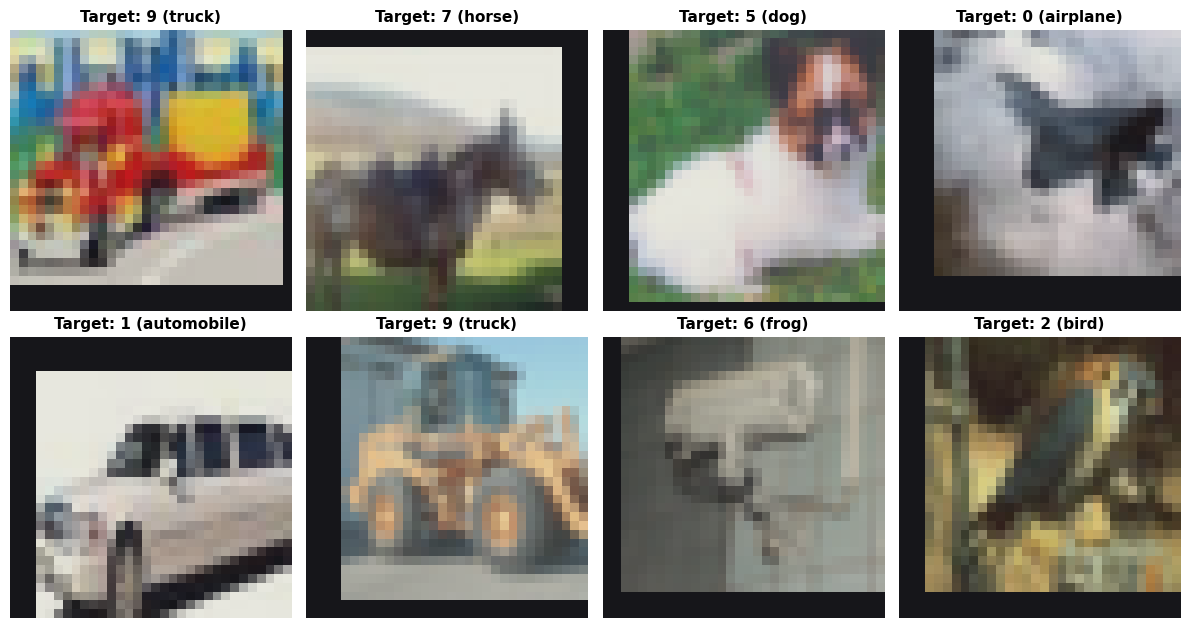

In [18]:
print("Visualizing Training Data (Pseudo-labels)...")
visualize_pseudo_labels(ft_data_train, num_samples=8, cols=4)

In [8]:
print("Visualizing Training Data (Pseudo-labels)...")
visualize_pseudo_labels(ft_data_val, num_samples=8, cols=4)

Visualizing Training Data (Pseudo-labels)...


NameError: name 'visualize_pseudo_labels' is not defined

--- Visualizing Victim Training Data (Standard CIFAR-10) ---


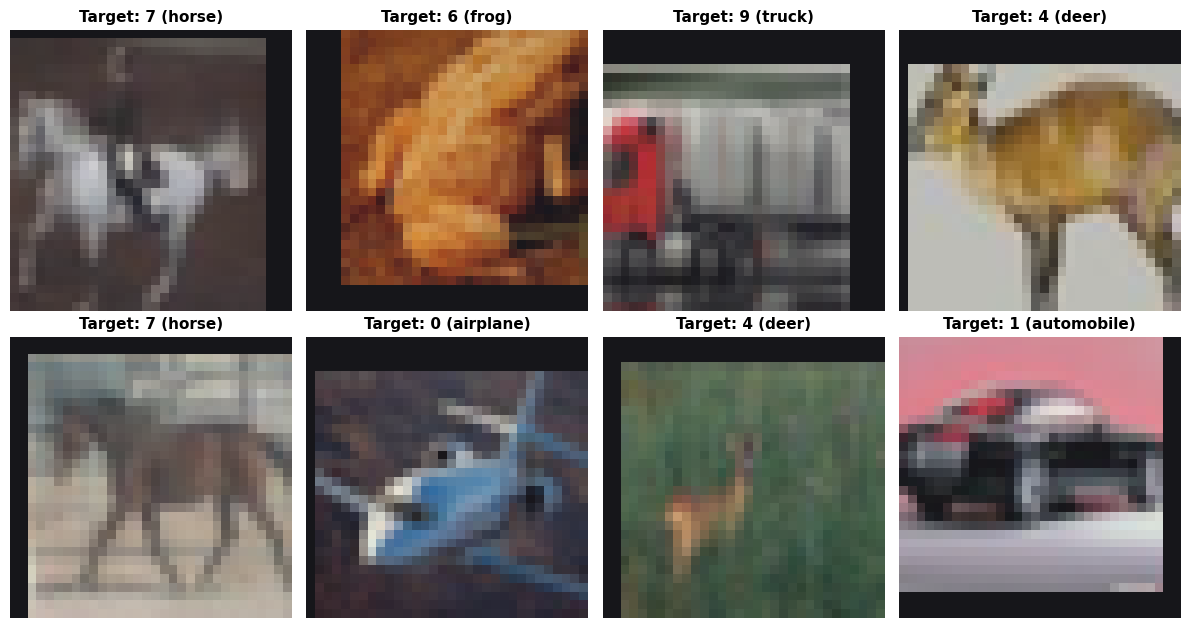

In [10]:
print("--- Visualizing Victim Training Data (Standard CIFAR-10) ---")
# Assuming your CIFAR-10 class exposes the train_set directly like your custom one does
standard_cifar10_train = exp_setup["Dataset"].train_set 
visualize_pseudo_labels(standard_cifar10_train, num_samples=8, cols=4)

In [17]:
group_A = create_or_load_group_A(dataset=exp_setup["Dataset"].train_set , save_dir=f'./Indices/{exp_yaml["Dataset"]["name"]}/',
                                        group_size=25000, num_classes=exp_setup["NumClasses"], seed=42, force_rebuild=False)

[INFO] Loading Group A from Indices\CIFAR-100\group_A_25000_seed42.npy


In [16]:
group_B = create_or_load_group_B(group_size=10000, overlap_rate=0.0, 
                                     save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/', group_A_indices=group_A,
                                     dataset = exp_setup["Dataset"].train_set, num_classes=exp_setup["NumClasses"],
                                     seed=42, force_rebuild=True)

[INFO] Creating Group B (overlap=0.0)


In [18]:
for rate in np.linspace(0,1,11):

    group_B = create_or_load_group_B(group_size=25000, overlap_rate=rate, 
                                     save_dir=f'./Indices/{exp_yaml['Dataset']['name']}/', group_A_indices=group_A,
                                     dataset = exp_setup["Dataset"].train_set, num_classes=exp_setup["NumClasses"],
                                     seed=42, force_rebuild=True)

[INFO] Creating Group B (overlap=0.0)
[INFO] Creating Group B (overlap=0.1)
[INFO] Creating Group B (overlap=0.2)
[INFO] Creating Group B (overlap=0.3)
[INFO] Creating Group B (overlap=0.4)
[INFO] Creating Group B (overlap=0.5)
[INFO] Creating Group B (overlap=0.6)
[INFO] Creating Group B (overlap=0.7)
[INFO] Creating Group B (overlap=0.8)
[INFO] Creating Group B (overlap=0.9)
[INFO] Creating Group B (overlap=1.0)


In [19]:
set_A = set(group_A)

In [20]:
set_B = set(group_B)

In [21]:
are_disjoint_1_2 = set_A.isdisjoint(set_B)
print(f"Set 1 and Set 2 are disjoint: {are_disjoint_1_2}")

Set 1 and Set 2 are disjoint: False


In [22]:
if (set_A == set_B):
    print(1)

1


In [23]:
group_C = group_A + group_B

In [27]:
group_A.sort()
group_A[-10:]

[49977, 49979, 49986, 49988, 49990, 49992, 49993, 49994, 49997, 49999]

In [28]:
group_B.sort()
group_B[-10:]

array([49977, 49979, 49986, 49988, 49990, 49992, 49993, 49994, 49997,
       49999])

In [24]:
group_C.sort()

In [25]:
group_C[-10:]

array([98764, 98819, 98956, 99012, 99095, 99101, 99440, 99446, 99490,
       99585])

In [26]:
group_C

array([  159,   404,   674, ..., 99446, 99490, 99585], shape=(25000,))

In [5]:
exp_yaml["FT_Dataset"]["name"]

hf_train_labels = exp_setup["FT_Dataset"].train_set.hf_dataset['label']
print(hf_train_labels)

idx_tr, idx_va = extract_ft_balanced_train_val_indices(
            Y=hf_train_labels, 
            split_size=exp_setup["FT_GroupSize"], 
            seed=42
        )

Column([8, 1, 2, 1, 3])


In [11]:
idx_tr

array([ 50631, 137629,  39640, ...,  77354,  83192,  17946],
      shape=(10000,))

In [12]:
idx_va

array([  8736,  53138, 162757, ...,   5390, 107078,  27448],
      shape=(10000,))

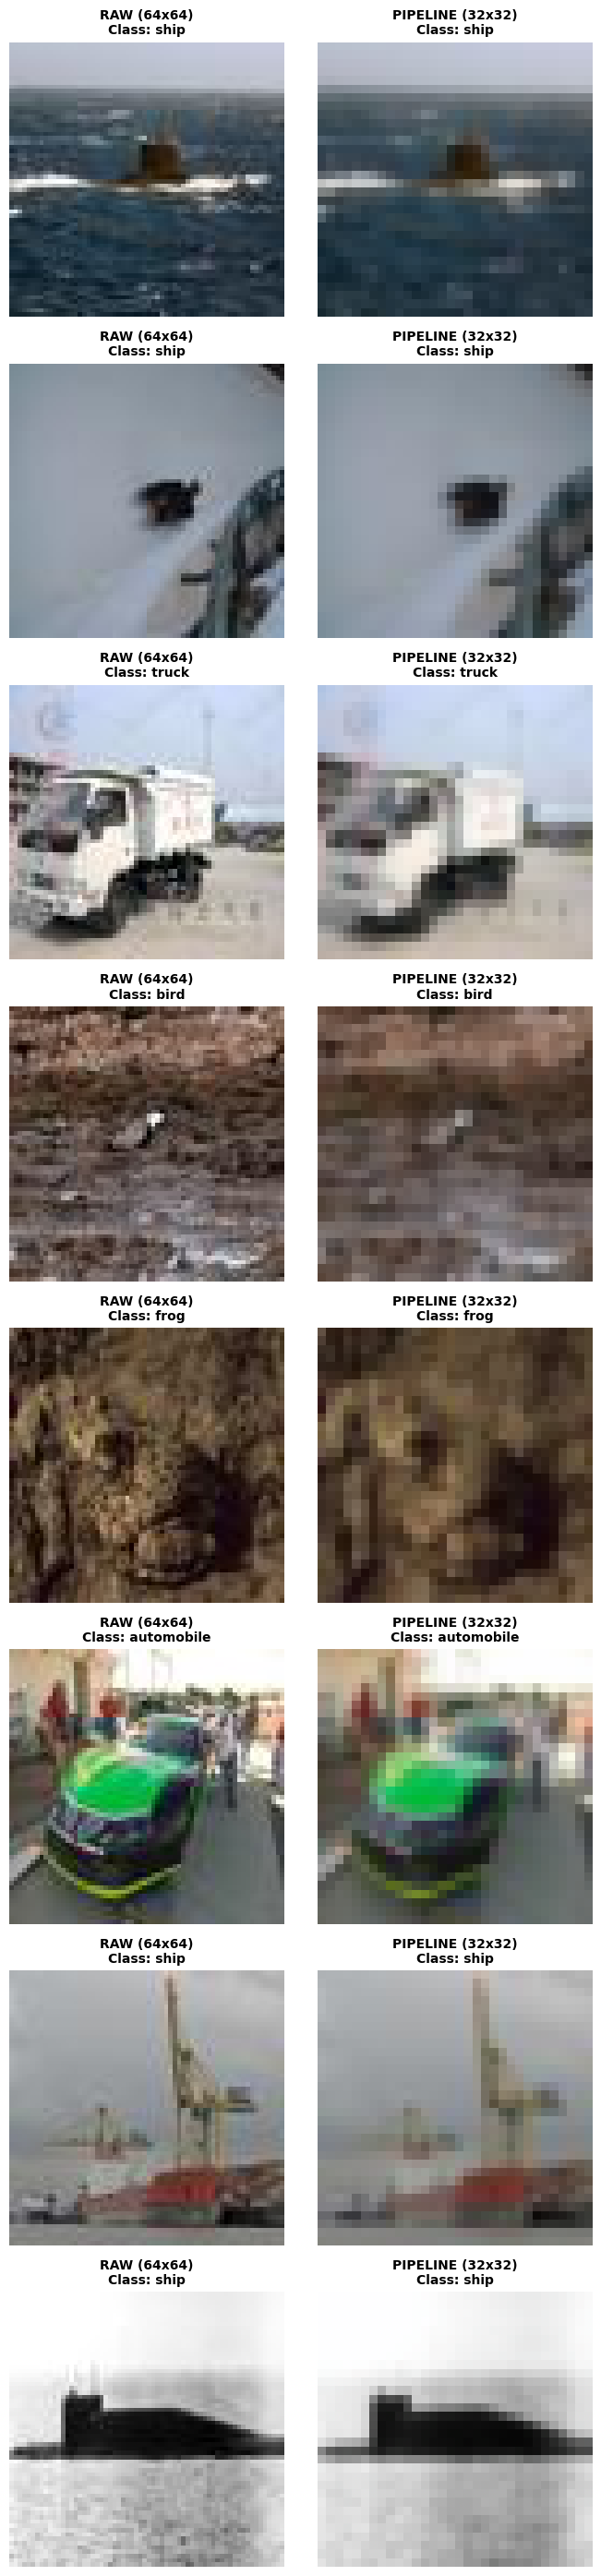

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_cifarnet_resolutions(dataset_obj, indices, num_samples=4):
    """
    Plots the raw 64x64 CIFARNet image next to the 32x32 pipeline output.
    """
    cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                     'dog', 'frog', 'horse', 'ship', 'truck']
    
    # Standard CIFAR-10 stats used in your pipeline
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2471, 0.2435, 0.2616])
    
    fig, axes = plt.subplots(num_samples, 2, figsize=(7, 3.5 * num_samples))
    
    for i, idx in enumerate(indices[:num_samples]):
        # -------------------------------------------------------------
        # 1. Get RAW 64x64 image directly from Hugging Face
        # -------------------------------------------------------------
        # dataset_obj.train_set is our HFImageDataset wrapper
        # .hf_dataset gives us the raw dictionary backend
        raw_item = dataset_obj.train_set.hf_dataset[int(idx)]
        
        # Dynamically find the correct image column name ('img' vs 'image')
        img_key = 'img' if 'img' in raw_item else 'image'
        
        raw_img = raw_item[img_key].convert("RGB")
        label = raw_item['label']
        
        # -------------------------------------------------------------
        # 2. Get PIPELINE 32x32 image 
        # -------------------------------------------------------------
        # We use `in_sample_set` here because it applies the test_transforms 
        # (Resize + Normalize). If we used `train_set`, RandomCrop and 
        # RandomFlip would mess up the direct side-by-side visual comparison!
        tensor_img, _ = dataset_obj.in_sample_set[int(idx)]
        
        # Denormalize and reshape for matplotlib
        img_32 = tensor_img.numpy().transpose((1, 2, 0))
        img_32 = std * img_32 + mean
        img_32 = np.clip(img_32, 0, 1)
        
        # -------------------------------------------------------------
        # 3. Plotting
        # -------------------------------------------------------------
        # Plot 64x64
        axes[i, 0].imshow(raw_img)
        axes[i, 0].set_title(f"RAW (64x64)\nClass: {cifar_classes[label]}", fontsize=10, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Plot 32x32
        axes[i, 1].imshow(img_32)
        axes[i, 1].set_title(f"PIPELINE (32x32)\nClass: {cifar_classes[label]}", fontsize=10, fontweight='bold')
        axes[i, 1].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run it using the first 4 indices from your training split!
visualize_cifarnet_resolutions(exp_setup["FT_Dataset"], idx_tr, num_samples=8)

In [1]:
from main_prune import *

exp_folder = "./saved_exp_plan/prune_plan"
yaml_files = sorted(glob.glob(os.path.join(exp_folder, "*.yaml")))

yaml_file_path = yaml_files[0]
print(yaml_file_path)

./saved_exp_plan/prune_plan\CIFAR10_RES18_PRUNE.yaml


In [2]:
exp_yaml = process_yaml_file(yaml_file_path)
exp_setup = process_experiment_prune_setup(exp_yaml)
print(exp_setup)

this time experiment blueprint:{'Model_Name': 'CIFAR-10_ResNet-18_40000', 'Scenario_Name': 'CIFAR-10_ResNet-18_40000_CIFARNet_10000', 'Dataset': {'name': 'CIFAR-10', 'normalization': 'cifar10', 'img_size': 32, 'train_transforms': [{'name': 'RandomCrop', 'params': {'size': 32, 'padding': 4}}, {'name': 'RandomHorizontalFlip', 'params': {'p': 0.5}}, {'name': 'ToTensor'}, {'name': 'Normalize'}], 'test_transforms': [{'name': 'ToTensor'}, {'name': 'Normalize'}], 'group_size': 40000}, 'FT_Dataset': {'name': 'CIFARNet', 'normalization': 'cifar10', 'img_size': 32, 'train_transforms': [{'name': 'RandomCrop', 'params': {'size': 32, 'padding': 4}}, {'name': 'RandomHorizontalFlip', 'params': {'p': 0.5}}, {'name': 'ToTensor'}, {'name': 'Normalize'}], 'test_transforms': [{'name': 'ToTensor'}, {'name': 'Normalize'}], 'group_size': 10000, 'note': 'different'}, 'Model': 'ResNet-18', 'Optimizers': [{'name': 'SGD', 'sparsity': 0.2, 'params': {'lr': 0.01, 'momentum': 0.9, 'weight_decay': 0.0005}, 'Epochs':

In [5]:
print('==> Loading model..')
model_name = exp_yaml["Model_Name"] + f"_{42}_{1.0}"
model_dir = './saved_models/vanilla/'
model_folder = Path(model_dir)/model_name

ckpt_path = load_best_checkpoint(model_folder) # find best checkpoint
if ckpt_path is None:
    print(f"[⚠️] No .pth files found in {model_folder}")
print(ckpt_path)

==> Loading model..
[📦] Loading best checkpoint: best_epoch.pth
saved_models\vanilla\CIFAR-10_ResNet-18_40000_42_1.0\best_epoch.pth


In [6]:
print('==> Building model..')
net = exp_setup["Model"].to(device) # load model 
state = torch.load(ckpt_path, map_location=device) # reset to original checkpoint
net.load_state_dict(state)
check_pruned_weights(net)

==> Building model..

=== PRUNING CHECKER ===

GLOBAL SPARSITY: 0.00%



np.float64(0.0)

In [7]:
pruned_net = prune_model_global(model=net, amount=0.2)
check_pruned_weights(pruned_net)


=== PRUNING CHECKER ===

GLOBAL SPARSITY: 20.00%



np.float64(19.999996417167782)

In [9]:
pruned_net = setup_finetune(model=pruned_net, strategy="FT-AL", device=device)
check_pruned_weights(pruned_net)


=== PRUNING CHECKER ===

GLOBAL SPARSITY: 20.00%



np.float64(19.999996417167782)

In [10]:
remove_prune_mask(pruned_net)
check_pruned_weights(pruned_net)


=== PRUNING CHECKER ===

GLOBAL SPARSITY: 20.00%



np.float64(19.999996417167782)

In [11]:
print('==> Building model..')
net = exp_setup["Model"].to(device) # load model 
state = torch.load(ckpt_path, map_location=device) # reset to original checkpoint
net.load_state_dict(state)
check_pruned_weights(net)

pruned_net = prune_model_global(model=net, amount=0.6)
check_pruned_weights(pruned_net)

==> Building model..

=== PRUNING CHECKER ===

GLOBAL SPARSITY: 0.00%


=== PRUNING CHECKER ===

GLOBAL SPARSITY: 60.00%



np.float64(59.9999982085839)